In [2]:
import os
import glob
import requests
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from openpyxl import load_workbook
from scipy.spatial.distance import cdist 
from statannotations.Annotator import Annotator

# Make sure GOC is bi-directional.

In [ ]:
humanMouseRecipricol = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/humanMouseReciprical.txt", sep="\t").rename(columns={"Gene stable ID": "MouseID", "Human gene stable ID": "HumanID"})

In [ ]:
orthologTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")

In [ ]:
orthologTableHumanGOC = orthologTable.merge(humanMouseRecipricol, left_on=["Gene stable ID", "Mouse gene stable ID"], right_on=["HumanID", "MouseID"], how="left").drop(columns=["MouseID", "HumanID"])
orthologTableHumanGOC.insert(3, "Human Gene-order conservation score", orthologTableHumanGOC.pop("Human Gene-order conservation score"))

# Identifying Duplicated Species

In [ ]:
orthoDist = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDist.parquet")
display(orthoDist)

In [ ]:
# Identifies the number of mouse genes associated with each human gene.
groupedHumanGene = orthoDist.groupby("Gene stable ID")["Mouse gene stable ID"].apply(list).reset_index(name="Mouse gene stable ID")

# Adds in the homology type to the dataframe.
groupedHumanGene = groupedHumanGene.merge(orthoDist.loc[:, ["Gene stable ID", "Mouse homology type"]])

# Identifies the human genes that have more than one mouse gene associated with them.
groupedHumanGene["Num Mouse Dupes"] = groupedHumanGene["Mouse gene stable ID"].apply(len)

# Creates a new column that identifies which one-to-many gene experienced a duplication event in humans. 
groupedHumanGene["Duplicated Species"] = np.where((groupedHumanGene["Gene stable ID"].isin(groupedHumanGene[groupedHumanGene["Num Mouse Dupes"] > 1]["Gene stable ID"])) & (groupedHumanGene["Mouse homology type"] == "ortholog_one2many"), "Mouse", "NA")

In [ ]:
groupedHumanGene

In [ ]:
# Transfers the information above to the orthologTableDist dataframe.
orthoDistHumanDup = orthoDist.merge(groupedHumanGene.loc[:, ["Gene stable ID", "Duplicated Species", "Num Mouse Dupes"]], left_on="Gene stable ID", right_on="Gene stable ID", how="outer")

In [ ]:
# Same steps as three cells above, but for mouse genes.
groupedMouseGene = orthoDist.groupby("Mouse gene stable ID")["Gene stable ID"].apply(list).reset_index(name="Gene stable ID")
groupedMouseGene = groupedMouseGene.merge(orthoDist.loc[:, ["Mouse gene stable ID", "Mouse homology type"]])
groupedMouseGene["Num Human Dupes"] = groupedMouseGene["Gene stable ID"].apply(len)
groupedMouseGene["Duplicated Species"] = np.where((groupedMouseGene["Mouse gene stable ID"].isin(groupedMouseGene[groupedMouseGene["Num Human Dupes"] > 1]["Mouse gene stable ID"])) & (groupedMouseGene["Mouse homology type"] == "ortholog_one2many"), "Human", "NA")

In [ ]:
groupedMouseGene[groupedMouseGene["Mouse gene stable ID"] == "ENSMUSG00000030945"]

In [ ]:
groupedMouseGene

In [ ]:
# Transfers the information above to the orthologDistTable dataframe.
orthoDistHumanMouseDup = orthoDistHumanDup.merge(groupedMouseGene.loc[:, ["Mouse gene stable ID", "Duplicated Species", "Num Human Dupes"]], on="Mouse gene stable ID", how="outer")

# Because there are two separate "Duplicated Species" columns, I am going to combine their information into one.
# If the human "Duplicated Species" column is "NA" then we use the mouse "Duplicated Species" column. It will either be "Mouse" or stay "NA."
orthoDistHumanMouseDup["Duplicated Species"] = np.where(orthoDistHumanMouseDup["Duplicated Species_x"] == "NA", orthoDistHumanMouseDup["Duplicated Species_y"], orthoDistHumanMouseDup["Duplicated Species_x"])

# Drop the two separate "Duplicated Species" columns.
orthoDistHumanMouseDup = orthoDistHumanMouseDup.loc[:, ~orthoDistHumanMouseDup.columns.isin(["Duplicated Species_x", "Duplicated Species_y"])].drop_duplicates()
display(orthoDistHumanMouseDup)

In [ ]:
orthoDistHumanMouseDup.columns[-1:]

In [ ]:
newColOrder = list(orthoDistHumanMouseDup.columns[:-3]) + list(orthoDistHumanMouseDup.columns[-2:-1]) + list(orthoDistHumanMouseDup.columns[-3:-2]) + list(orthoDistHumanMouseDup.columns[-1:])
orthoDistHumanMouseDup = orthoDistHumanMouseDup.loc[:, newColOrder]

In [ ]:
orthoDistHumanMouseDup.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupe.csv", index=False)
orthoDistHumanMouseDup.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupe.parquet", index=False)

In [ ]:
gtexEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/gtexExpressionProfile.parquet")
emtabEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/emtabExpressionProfile.parquet")

In [ ]:
gtexEP

In [ ]:
emtabEP

In [ ]:
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDup.merge(gtexEP.loc[:, ["Gene type"]], left_on="Gene stable ID", right_index=True, how="left")
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDupBioType.rename(columns={"Gene type": "Human Gene Type"})

In [ ]:
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDupBioType.merge(emtabEP.loc[:, ["Gene type"]], left_on="Mouse gene stable ID", right_index=True, how="left")
orthoDistHumanMouseDupBioType = orthoDistHumanMouseDupBioType.rename(columns={"Gene type": "Mouse Gene Type"})

In [ ]:
orthoDistHumanMouseDupBioType

In [ ]:
orthoDistHumanMouseDupBioType.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.csv")
orthoDistHumanMouseDupBioType.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")

# Statistical Analysis

In [ ]:
data = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")
dataProteinOnly = data[(data["Human Gene Type"] == "protein_coding") & (data["Mouse Gene Type"] == "protein_coding")]

In [ ]:
dataProteinOnly

In [ ]:
dataProteinOnly[dataProteinOnly["Mouse homology type"] == "ortholog_one2one"]["EuclidDistNorm"].dropna()

In [ ]:
dataProteinOnly[dataProteinOnly["Mouse homology type"] == "ortholog_one2one"]["TEC"].dropna()

In [ ]:
statsDF = pd.DataFrame({
    "Category": ["one-to-one", 
                 "one-to-many", "one-to-many, duplicated in human", "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                 "one-to-many, duplicated in mouse", "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                 "many-to-many"],
    "n": "",
    "Median": "",
    "Mean": ""
})

In [ ]:
statsDF

In [ ]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many"
}

In [ ]:
statsDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    nArr = []
    medianArr = []
    meanArr = []

    for category in statsDF["Category"]:
        categoryParts = category.split(", ")
        translatedParts = list(map(translationTable.get, categoryParts))
        if len(translatedParts) == 1:
            filteredDF = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedParts[0]][distMetric].dropna()
        elif len(translatedParts) == 2:
            filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1])][distMetric].dropna()
        else:
            filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedParts[2])][distMetric].dropna()

        nArr.append(filteredDF.shape[0])
        medianArr.append(filteredDF.median())
        meanArr.append(filteredDF.mean())

    statsDF["n"] = nArr
    statsDF["Median"] = medianArr
    statsDF["Mean"] = meanArr
    statsDFArr.append(statsDF.copy())

In [ ]:
statsDFArr

In [ ]:
pValueDF = pd.DataFrame({
    "Group 1": ["one-to-one", "one-to-one",
                "one-to-many, duplicated in human",
                "many-to-many", "many-to-many",
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=0",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=0"],

    "Group 2": ["one-to-many, duplicated in human", "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human", "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100", "one-to-many, duplicated in mouse, GOC=100"],
    "P-value": ""
})

In [ ]:
pValueDF

In [ ]:
pValueDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    pValueArr = []
    for rowNum in range(pValueDF.shape[0]):
        translatedGroup1 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[0].split(", ")))
        translatedGroup2 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[1].split(", ")))

        if len(translatedGroup1) == 1:
            filteredDF1 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup1[0]][distMetric].dropna()
        elif len(translatedGroup1) == 2:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1])][distMetric].dropna()
        else:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup1[2])][distMetric].dropna()
        
        if len(translatedGroup2) == 1:
            filteredDF2 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup2[0]][distMetric].dropna()
        elif len(translatedGroup2) == 2:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1])][distMetric].dropna()
        else:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup2[2])][distMetric].dropna()

        pValueArr.append(stats.mannwhitneyu(filteredDF1, filteredDF2)[1])

    pValueDF["P-value"] = pValueArr
    pValueDFArr.append(pValueDF.copy())

In [ ]:
emptyCols = pd.DataFrame({
    "": [np.nan] * len(statsDF),
    " ": [np.nan] * len(statsDF)
})


with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistances.xlsx") as w:
    for idx, distMetric in enumerate(dataProteinOnly.columns[4:9]):
        finalDF = pd.concat([statsDFArr[idx].astype(str), emptyCols, pValueDFArr[idx].astype(str)], axis=1)
        finalDF.to_excel(w, sheet_name=distMetric, index=False)

In [ ]:
statsDFArr

# Random Sampling

In [ ]:
# TEC
def TEC(humanOrtholog, mouseOrtholog):
    # Turns the vectors binary. So if the expression is greater than 1, we consider that "expressed."
    humanOrthoBinary = (humanOrtholog.iloc[:, :-1] > 1).iloc[0, :]
    mouseOrthoBinary = (mouseOrtholog.iloc[:, :-1] > 1).iloc[0, :]

    humanOnlyTissueNum = (humanOrthoBinary & ~mouseOrthoBinary).sum()
    mouseOnlyTissueNum = (mouseOrthoBinary & ~humanOrthoBinary).sum()

    humanTotalTissue = humanOrthoBinary.sum()
    mouseTotalTissue = mouseOrthoBinary.sum()

    if humanTotalTissue == 0 and mouseTotalTissue == 0:
        return np.nan
    elif humanTotalTissue == 0 or mouseTotalTissue == 0:
        return np.nan
    else:
        return ((humanOnlyTissueNum / humanTotalTissue) + (mouseOnlyTissueNum / mouseTotalTissue)) / 2


In [ ]:
columns = ["HumanID", "MouseID", "EuclidDist", "EuclidDistNorm", "EuclidDistLog", "PearDist", "TEC"]
sampleDF = pd.DataFrame(columns=columns)

In [ ]:
gtexEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/gtexExpressionProfile.parquet")
emtabEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/emtabExpressionProfile.parquet")

In [ ]:
gtexEPProteinOnly = gtexEP[gtexEP["Gene type"] == "protein_coding"]
emtabEPProteinOnly = emtabEP[emtabEP["Gene type"] == "protein_coding"]

In [ ]:
# humanGenes = gtexEPProteinOnly.sample(10000, replace=False)
# mouseGenes = emtabEPProteinOnly.sample(10000, replace=False)

In [ ]:
# pd.DataFrame({
#     "Human ID": humanGenes.index,
#     "Mouse ID": mouseGenes.index
# }).to_csv("/Users/andrewhsu/Projects/McNair/data/randomGeneIDs.csv", index=False)

In [ ]:
geneIDs = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/randomGeneIDs.csv")

In [ ]:
humanGenes = gtexEPProteinOnly[gtexEPProteinOnly.index.isin(geneIDs["Human ID"])]
mouseGenes = emtabEPProteinOnly[emtabEPProteinOnly.index.isin(geneIDs["Mouse ID"])]

In [ ]:
humanGenes

In [ ]:
humanGenesNorm = humanGenes.iloc[:, :-1].div(np.linalg.norm(humanGenes.iloc[:, :-1], axis=1), axis=0)
mouseGenesNorm = mouseGenes.iloc[:, :-1].div(np.linalg.norm(mouseGenes.iloc[:, :-1], axis=1), axis=0)

In [ ]:
humanGenesLog = np.log2(humanGenes.iloc[:, :-1] + 1)
mouseGenesLog = np.log2(mouseGenes.iloc[:, :-1] + 1)

In [ ]:
euclidDist = np.linalg.norm(humanGenes.iloc[:, :-1] - mouseGenes.iloc[:, :-1].values, axis=1)

In [ ]:
euclidDistNorm = np.linalg.norm(humanGenesNorm - mouseGenesNorm.values, axis=1)

In [ ]:
euclidDistLog = np.linalg.norm(humanGenesLog - mouseGenesLog.values, axis=1)

In [ ]:
humanGenesLog - mouseGenesLog.values

In [ ]:
pearDist = np.diag(cdist(humanGenes.iloc[:, :-1].values.astype(float), mouseGenes.iloc[:, :-1].values.astype(float), metric="correlation"))

In [ ]:
tecValues = [TEC(humanGenes.iloc[rowIdx: rowIdx + 1], mouseGenes.iloc[rowIdx: rowIdx + 1])for rowIdx in range(humanGenes.shape[0])]

In [ ]:
sampleDF["HumanID"] = humanGenes.index
sampleDF["MouseID"] = mouseGenes.index
sampleDF["EuclidDist"] = euclidDist
sampleDF["EuclidDistNorm"] = euclidDistNorm
sampleDF["EuclidDistLog"] = euclidDistLog
sampleDF["PearDist"] = pearDist
sampleDF["TEC"] = tecValues

In [ ]:
sampleDF.to_csv("/Users/andrewhsu/Projects/McNair/data/randomGenesTable.csv", index=False)
sampleDF.to_parquet("/Users/andrewhsu/Projects/McNair/data/randomGenesTable.parquet", index=False)

# Statistical Analysis for Random Samples

In [ ]:
data = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")
dataProteinOnly = data[(data["Human Gene Type"] == "protein_coding") & (data["Mouse Gene Type"] == "protein_coding")]

randomData = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/randomGenesTable.parquet")

In [ ]:
randomData

In [ ]:
statsDF = pd.DataFrame({
    "Category": ["one-to-one", 
                 "one-to-many", "one-to-many, duplicated in human", "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                 "one-to-many, duplicated in mouse", "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                 "many-to-many", "random"],
    "n": "",
    "Median": "",
    "Mean": ""
})

pValueDF = pd.DataFrame({
    "Group 1": ["one-to-one", "one-to-one",
                "one-to-many, duplicated in human",
                "many-to-many", "many-to-many",
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=0",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=0"],

    "Group 2": ["one-to-many, duplicated in human", "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human", "one-to-many, duplicated in mouse", 
                "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100", "one-to-many, duplicated in mouse, GOC=100"],
    "P-value": ""
})

In [ ]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many"
}

In [ ]:
statsDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    nArr = []
    medianArr = []
    meanArr = []

    for category in statsDF["Category"]:
        if category == "random":
            filteredDF = randomData[distMetric].dropna()
        else:
            categoryParts = category.split(", ")
            translatedParts = list(map(translationTable.get, categoryParts))
            if len(translatedParts) == 1:
                filteredDF = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedParts[0]][distMetric].dropna()
            elif len(translatedParts) == 2:
                filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1])][distMetric].dropna()
            else:
                filteredDF = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedParts[0]) & (dataProteinOnly["Duplicated Species"] == translatedParts[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedParts[2])][distMetric].dropna()

        nArr.append(filteredDF.shape[0])
        medianArr.append(filteredDF.median())
        meanArr.append(filteredDF.mean())

    statsDF["n"] = nArr
    statsDF["Median"] = medianArr
    statsDF["Mean"] = meanArr
    statsDFArr.append(statsDF.copy())

In [ ]:
pValueDFArr = []
for distMetric in dataProteinOnly.columns[4:9]:
    pValueArr = []
    for rowNum in range(pValueDF.shape[0]):
        translatedGroup1 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[0].split(", ")))
        translatedGroup2 = list(map(translationTable.get, pValueDF.iloc[rowNum, :].iloc[1].split(", ")))

        if len(translatedGroup1) == 1:
            filteredDF1 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup1[0]][distMetric].dropna()
        elif len(translatedGroup1) == 2:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1])][distMetric].dropna()
        else:
            filteredDF1 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup1[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup1[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup1[2])][distMetric].dropna()
        
        if len(translatedGroup2) == 1:
            filteredDF2 = dataProteinOnly[dataProteinOnly["Mouse homology type"] == translatedGroup2[0]][distMetric].dropna()
        elif len(translatedGroup2) == 2:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1])][distMetric].dropna()
        else:
            filteredDF2 = dataProteinOnly[(dataProteinOnly["Mouse homology type"] == translatedGroup2[0]) & (dataProteinOnly["Duplicated Species"] == translatedGroup2[1]) & (dataProteinOnly["Mouse Gene-order conservation score"] == translatedGroup2[2])][distMetric].dropna()

        pValueArr.append(stats.mannwhitneyu(filteredDF1, filteredDF2)[1])

    pValueDF["P-value"] = pValueArr
    pValueDFArr.append(pValueDF.copy())

In [ ]:
emptyCols = pd.DataFrame({
    "": [np.nan] * len(statsDF),
    " ": [np.nan] * len(statsDF)
})


with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom.xlsx") as w:
    for idx, distMetric in enumerate(dataProteinOnly.columns[4:9]):
        finalDF = pd.concat([statsDFArr[idx].astype(str), emptyCols, pValueDFArr[idx].astype(str)], axis=1)
        finalDF.to_excel(w, sheet_name=distMetric, index=False)

# Parental-Daughter Identification

In [111]:
humanColumns = ["Human Gene", "Mouse Parent", "Mouse Daughter", "GOC Parent", "GOC Daughter", "EuclidDist Parent", "EuclidDist Daughter", "EuclidDistNorm Parent", "EuclidDistNorm Daughter", "EuclidDistLog Parent", "EuclidDistLog Daughter", "PearDist Parent", "PearDist Daughter", "TEC Parent", "TEC Daughter"]
mouseColumns = ["Mouse Gene", "Human Parent", "Human Daughter", "GOC Parent", "GOC Daughter", "EuclidDist Parent", "EuclidDist Daughter", "EuclidDistNorm Parent", "EuclidDistNorm Daughter", "EuclidDistLog Parent", "EuclidDistLog Daughter", "PearDist Parent", "PearDist Daughter", "TEC Parent", "TEC Daughter"]
humanParent = pd.DataFrame()
mouseParent = pd.DataFrame()

In [112]:
orthologTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioType.parquet")
humanParentTable = orthologTable[(orthologTable["Mouse homology type"] == "ortholog_one2many") & (orthologTable["Duplicated Species"] == "Mouse")].dropna(subset=["EuclidDist", "EuclidDistNorm", "EuclidDistLog", "PearDist", "TEC"])
mouseParentTable = orthologTable[(orthologTable["Mouse homology type"] == "ortholog_one2many") & (orthologTable["Duplicated Species"] == "Human")].dropna(subset=["EuclidDist", "EuclidDistNorm", "EuclidDistLog", "PearDist", "TEC"])

In [113]:
orthologTable["Parental"] = False
orthologTable["Daughter"] = False

In [114]:
humanParentRows = []
for humanID in humanParentTable["Gene stable ID"].unique():
    humanIDDF = humanParentTable[humanParentTable["Gene stable ID"] == humanID]
    humanMaxGOC = humanIDDF["Mouse Gene-order conservation score"].max()
    humanMinGOC = humanIDDF["Mouse Gene-order conservation score"].min()

    if humanMaxGOC != humanMinGOC:
        parentalCopy = humanIDDF[humanIDDF["Mouse Gene-order conservation score"] == humanMaxGOC]
        daughterCopy = humanIDDF[humanIDDF["Mouse Gene-order conservation score"] == humanMinGOC]

        orthologTable.loc[orthologTable["Mouse gene stable ID"].isin(parentalCopy["Mouse gene stable ID"]), "Parental"] = True
        orthologTable.loc[orthologTable["Mouse gene stable ID"].isin(daughterCopy["Mouse gene stable ID"]), "Daughter"] = True

        parentalCopyNAMin = parentalCopy[parentalCopy.isna().sum(axis=1) == parentalCopy.isna().sum(axis=1).min()].sample(n=1)
        daughterCopyNAMin = daughterCopy[daughterCopy.isna().sum(axis=1) == daughterCopy.isna().sum(axis=1).min()].sample(n=1)

        humanParentRow = [humanID, parentalCopyNAMin["Mouse gene stable ID"].item(), daughterCopyNAMin["Mouse gene stable ID"].item(), 
                        parentalCopyNAMin["Mouse Gene-order conservation score"].item(), daughterCopyNAMin["Mouse Gene-order conservation score"].item(),
                        parentalCopyNAMin["EuclidDist"].item(), daughterCopyNAMin["EuclidDist"].item(),
                        parentalCopyNAMin["EuclidDistNorm"].item(), daughterCopyNAMin["EuclidDistNorm"].item(),
                        parentalCopyNAMin["EuclidDistLog"].item(), daughterCopyNAMin["EuclidDistLog"].item(),
                        parentalCopyNAMin["PearDist"].item(), daughterCopyNAMin["PearDist"].item(),
                        parentalCopyNAMin["TEC"].item(), daughterCopyNAMin["TEC"].item()]
        humanParentRows.append(humanParentRow)
humanParent = pd.DataFrame(humanParentRows)
humanParent.columns = humanColumns

In [115]:
humanParent

,Human Gene,Mouse Parent,Mouse Daughter,GOC Parent,GOC Daughter,EuclidDist Parent,EuclidDist Daughter,EuclidDistNorm Parent,EuclidDistNorm Daughter,EuclidDistLog Parent,EuclidDistLog Daughter,PearDist Parent,PearDist Daughter,TEC Parent,TEC Daughter
0,ENSG00000254647,ENSMUSG00000000215,ENSMUSG00000035804,100.0,0.0,3667.846303,5264.286219,0.001498,0.001428,2.445157,4.066262,5.970543e-07,8.228542e-07,0.583333,0.250000
1,ENSG00000069493,ENSMUSG00000030157,ENSMUSG00000000248,50.0,0.0,495.295522,8.910251,0.940933,0.994561,11.994275,3.925919,1.027792e+00,6.630076e-01,0.000000,0.437500
2,ENSG00000157601,ENSMUSG00000023341,ENSMUSG00000000386,75.0,25.0,31.889421,31.041610,0.814844,0.718185,5.317110,6.218484,1.319186e+00,7.603217e-01,0.062500,0.187500
3,ENSG00000146425,ENSMUSG00000092074,ENSMUSG00000096255,50.0,0.0,350.275803,344.134492,0.417986,0.488780,14.297896,11.645987,3.814216e-01,6.034510e-01,0.187500,0.000000
4,ENSG00000089127,ENSMUSG00000052776,ENSMUSG00000001168,100.0,0.0,26.897303,20.208340,0.872478,0.943921,3.505326,6.439363,6.335573e-01,7.247547e-01,0.071429,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,ENSG00000196368,ENSMUSG00000073295,ENSMUSG00000073293,50.0,0.0,8.527966,6.592881,0.262621,0.258627,2.842869,2.658245,2.910398e-02,2.340353e-02,0.650000,0.300000
61,ENSG00000213927,ENSMUSG00000073888,ENSMUSG00000073877,50.0,25.0,66.857742,2.247779,0.605687,0.779310,6.851882,1.889789,1.983540e-01,1.964614e-01,0.312500,0.333333
62,ENSG00000100911,ENSMUSG00000079197,ENSMUSG00000078153,100.0,0.0,134.384423,221.839422,0.505016,0.643672,2.627622,13.149541,4.824525e-01,1.029902e+00,0.000000,0.250000
63,ENSG00000140379,ENSMUSG00000089929,ENSMUSG00000099974,50.0,0.0,8.795413,9.956477,0.847790,0.848279,2.634540,4.314749,9.625985e-01,1.088391e+00,0.314286,0.428571


In [116]:
humanParent.to_csv("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.csv", index=False)
humanParent.to_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet", index=False)

In [117]:
humanParent

,Human Gene,Mouse Parent,Mouse Daughter,GOC Parent,GOC Daughter,EuclidDist Parent,EuclidDist Daughter,EuclidDistNorm Parent,EuclidDistNorm Daughter,EuclidDistLog Parent,EuclidDistLog Daughter,PearDist Parent,PearDist Daughter,TEC Parent,TEC Daughter
0,ENSG00000254647,ENSMUSG00000000215,ENSMUSG00000035804,100.0,0.0,3667.846303,5264.286219,0.001498,0.001428,2.445157,4.066262,5.970543e-07,8.228542e-07,0.583333,0.250000
1,ENSG00000069493,ENSMUSG00000030157,ENSMUSG00000000248,50.0,0.0,495.295522,8.910251,0.940933,0.994561,11.994275,3.925919,1.027792e+00,6.630076e-01,0.000000,0.437500
2,ENSG00000157601,ENSMUSG00000023341,ENSMUSG00000000386,75.0,25.0,31.889421,31.041610,0.814844,0.718185,5.317110,6.218484,1.319186e+00,7.603217e-01,0.062500,0.187500
3,ENSG00000146425,ENSMUSG00000092074,ENSMUSG00000096255,50.0,0.0,350.275803,344.134492,0.417986,0.488780,14.297896,11.645987,3.814216e-01,6.034510e-01,0.187500,0.000000
4,ENSG00000089127,ENSMUSG00000052776,ENSMUSG00000001168,100.0,0.0,26.897303,20.208340,0.872478,0.943921,3.505326,6.439363,6.335573e-01,7.247547e-01,0.071429,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,ENSG00000196368,ENSMUSG00000073295,ENSMUSG00000073293,50.0,0.0,8.527966,6.592881,0.262621,0.258627,2.842869,2.658245,2.910398e-02,2.340353e-02,0.650000,0.300000
61,ENSG00000213927,ENSMUSG00000073888,ENSMUSG00000073877,50.0,25.0,66.857742,2.247779,0.605687,0.779310,6.851882,1.889789,1.983540e-01,1.964614e-01,0.312500,0.333333
62,ENSG00000100911,ENSMUSG00000079197,ENSMUSG00000078153,100.0,0.0,134.384423,221.839422,0.505016,0.643672,2.627622,13.149541,4.824525e-01,1.029902e+00,0.000000,0.250000
63,ENSG00000140379,ENSMUSG00000089929,ENSMUSG00000099974,50.0,0.0,8.795413,9.956477,0.847790,0.848279,2.634540,4.314749,9.625985e-01,1.088391e+00,0.314286,0.428571


In [118]:
mouseParentRows = []
for mouseID in mouseParentTable["Mouse gene stable ID"].unique():
    mouseIDDF = mouseParentTable[mouseParentTable["Mouse gene stable ID"] == mouseID]
    mouseMaxGOC = mouseIDDF["Mouse Gene-order conservation score"].max()
    mouseMinGOC = mouseIDDF["Mouse Gene-order conservation score"].min()

    if mouseMaxGOC != mouseMinGOC:
        parentalCopy = mouseIDDF[mouseIDDF["Mouse Gene-order conservation score"] == mouseMaxGOC]
        daughterCopy = mouseIDDF[mouseIDDF["Mouse Gene-order conservation score"] == mouseMinGOC]

        orthologTable.loc[orthologTable["Gene stable ID"].isin(parentalCopy["Gene stable ID"]), "Parental"] = True
        orthologTable.loc[orthologTable["Gene stable ID"].isin(daughterCopy["Gene stable ID"]), "Daughter"] = True

        parentalCopyNAMin = parentalCopy[parentalCopy.isna().sum(axis=1) == parentalCopy.isna().sum(axis=1).min()].sample(n=1)
        daughterCopyNAMin = daughterCopy[daughterCopy.isna().sum(axis=1) == daughterCopy.isna().sum(axis=1).min()].sample(n=1)

        mouseParentRow = [mouseID, parentalCopyNAMin["Gene stable ID"].item(), daughterCopyNAMin["Gene stable ID"].item(), 
                        parentalCopyNAMin["Mouse Gene-order conservation score"].item(), daughterCopyNAMin["Mouse Gene-order conservation score"].item(),
                        parentalCopyNAMin["EuclidDist"].item(), daughterCopyNAMin["EuclidDist"].item(),
                        parentalCopyNAMin["EuclidDistNorm"].item(), daughterCopyNAMin["EuclidDistNorm"].item(),
                        parentalCopyNAMin["EuclidDistLog"].item(), daughterCopyNAMin["EuclidDistLog"].item(),
                        parentalCopyNAMin["PearDist"].item(), daughterCopyNAMin["PearDist"].item(),
                        parentalCopyNAMin["TEC"].item(), daughterCopyNAMin["TEC"].item()]
        mouseParentRows.append(mouseParentRow)
mouseParent = pd.DataFrame(mouseParentRows)
mouseParent.columns = mouseColumns

In [119]:
mouseParent.to_csv("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.csv", index=False)
mouseParent.to_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet", index=False)

In [120]:
mouseParent

,Mouse Gene,Human Parent,Human Daughter,GOC Parent,GOC Daughter,EuclidDist Parent,EuclidDist Daughter,EuclidDistNorm Parent,EuclidDistNorm Daughter,EuclidDistLog Parent,EuclidDistLog Daughter,PearDist Parent,PearDist Daughter,TEC Parent,TEC Daughter
0,ENSMUSG00000000308,ENSG00000237289,ENSG00000223572,100.0,75.0,2561.844409,2569.930198,1.182314,0.869675,11.026921,12.033288,0.921149,0.554442,0.187500,0.187500
1,ENSMUSG00000000804,ENSG00000170832,ENSG00000129204,50.0,0.0,94.660307,115.484260,0.495699,0.769929,4.109197,10.174987,0.335662,0.869201,0.000000,0.375000
2,ENSMUSG00000000982,ENSG00000276085,ENSG00000275385,25.0,0.0,2.832792,10.376588,0.770763,1.049001,1.930052,4.076298,1.047197,1.147996,1.000000,0.333333
3,ENSMUSG00000002546,ENSG00000167110,ENSG00000215252,75.0,0.0,60.192802,121.247336,0.436744,0.939228,3.662404,5.696401,0.358321,1.411449,0.000000,0.000000
4,ENSMUSG00000003531,ENSG00000128185,ENSG00000183628,50.0,25.0,83.452811,212.162763,0.329774,0.631549,1.539677,11.598851,0.385749,0.725516,0.000000,0.000000
5,ENSMUSG00000004952,ENSG00000170667,ENSG00000105808,75.0,25.0,53.876346,54.686442,0.516873,0.524093,6.558534,6.969370,0.267796,0.276735,0.083333,0.166667
6,ENSMUSG00000014177,ENSG00000175106,ENSG00000171928,100.0,0.0,153.236129,132.435810,0.419002,0.490967,11.477241,6.241976,0.713338,0.871988,0.125000,0.000000
7,ENSMUSG00000018930,ENSG00000275302,ENSG00000276070,50.0,0.0,15.866463,2.410495,0.858253,0.862215,5.169542,1.768772,1.164840,1.206509,0.437500,1.000000
8,ENSMUSG00000020415,ENSG00000164611,ENSG00000250254,100.0,0.0,201.140082,213.565596,0.817359,0.594065,10.357073,13.980421,0.825432,0.634455,0.062500,0.437500
9,ENSMUSG00000020691,ENSG00000087995,ENSG00000165055,50.0,0.0,36.648051,32.884744,0.349616,0.338172,4.840102,3.970983,0.454175,0.415072,0.000000,0.000000


In [121]:
humanStats = {}
for distMetric in humanParent.columns[5::2]:
    numParentalHigher = (humanParent[distMetric] > humanParent[distMetric.replace("Parent", "Daughter")]).sum()
    numDaughterHigher = (humanParent[distMetric] < humanParent[distMetric.replace("Parent", "Daughter")]).sum()
    numEqual = (humanParent[distMetric] == humanParent[distMetric.replace("Parent", "Daughter")]).sum()
    humanStats[distMetric.replace(" Parent", "")] = [numParentalHigher, numDaughterHigher, numEqual]

humanStatsDF = pd.DataFrame(humanStats)
humanStatsDF.index = ["Parental", "Daughter", "Equal"]

In [122]:
humanStatsDF

,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC
Parental,27,18,18,22,11
Daughter,38,47,47,43,43
Equal,0,0,0,0,11


In [123]:
mouseStats = {}
for distMetric in mouseParent.columns[5::2]:
    numParentalHigher = (mouseParent[distMetric] > mouseParent[distMetric.replace("Parent", "Daughter")]).sum()
    numDaughterHigher = (mouseParent[distMetric] < mouseParent[distMetric.replace("Parent", "Daughter")]).sum()
    numEqual = (mouseParent[distMetric] == mouseParent[distMetric.replace("Parent", "Daughter")]).sum()
    mouseStats[distMetric.replace(" Parent", "")] = [numParentalHigher, numDaughterHigher, numEqual]

mouseStatsDF = pd.DataFrame(mouseStats)
mouseStatsDF.index = ["Parental", "Daughter", "Equal"]

In [124]:
mouseStatsDF

,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC
Parental,15,13,17,13,4
Daughter,28,30,26,30,20
Equal,0,0,0,0,19


In [125]:
humanStatsT = humanStatsDF.T.iloc[:, :-1]
humanStatsT["Binomial pValue"] = [stats.binomtest(k, n, alternative="greater").pvalue for k, n in zip(humanStatsT["Daughter"], humanStatsT["Daughter"] + humanStatsT["Parental"])]
humanStatsT["Wilcoxon pValue"] = [stats.wilcoxon(humanParent[distMetric.replace("Parent", "Daughter")], humanParent[distMetric], alternative="greater").pvalue for distMetric in humanParent.columns[5::2]]

mouseStatsT = mouseStatsDF.T.iloc[:, :-1]
mouseStatsT["Binomial pValue"] = [stats.binomtest(k, n, alternative="greater").pvalue for k, n in zip(humanStatsT["Daughter"], humanStatsT["Daughter"] + humanStatsT["Parental"])]
mouseStatsT["Wilcoxon pValue"] = [stats.wilcoxon(mouseParent[distMetric.replace("Parent", "Daughter")], mouseParent[distMetric], alternative="greater").pvalue for distMetric in mouseParent.columns[5::2]]

In [126]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/parentDaughterStats.xlsx") as w:
    humanStatsT.T.astype(str).to_excel(w, sheet_name="Mouse", index=True)
    mouseStatsT.T.astype(str).to_excel(w, sheet_name="Human", index=True)

In [127]:
orthologTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.csv")
orthologTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")

# Parental-Daughter Analysis

In [ ]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")

In [ ]:
orthoTable

In [ ]:
parentalDaughterDF = pd.DataFrame({
    "Categories": ["trios, duplicated in human, parental", "trios, duplicated in human, daughter",
                   "trios, duplicated in mouse, parental", "trios, duplicated in mouse, daughter"],
    "n": "",
    "Median": "",
    "Mean": ""
})

In [ ]:
translationTable = {
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parental",
    "daughter": "Daughter"
}

In [ ]:
masterDF = []
for distMetric in orthoTable.columns[4:9]:
    nArr = []
    medianArr = []
    meanArr = []
    for category in parentalDaughterDF["Categories"]:
        translatedCats = list(map(translationTable.get, category.split(", ")))
        n = orthoTable[(orthoTable["Mouse homology type"] == translatedCats[0]) & (orthoTable["Duplicated Species"] == translatedCats[1]) & (orthoTable[translatedCats[2]] == True)][distMetric].dropna().shape[0]
        median = orthoTable[(orthoTable["Mouse homology type"] == translatedCats[0]) & (orthoTable["Duplicated Species"] == translatedCats[1]) & (orthoTable[translatedCats[2]] == True)][distMetric].dropna().median()
        mean = orthoTable[(orthoTable["Mouse homology type"] == translatedCats[0]) & (orthoTable["Duplicated Species"] == translatedCats[1]) & (orthoTable[translatedCats[2]] == True)][distMetric].dropna().mean()

        nArr.append(n)
        medianArr.append(median)
        meanArr.append(mean)

    parentalDaughterDF["n"] = nArr
    parentalDaughterDF["Median"] = medianArr
    parentalDaughterDF["Mean"] = meanArr
    masterDF.append(parentalDaughterDF.copy())

In [ ]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx", mode="a", if_sheet_exists="overlay") as w:
    for idx, distMetric in enumerate(orthoTable.columns[4:9]):
        masterDF[idx].to_excel(w, sheet_name=distMetric, startrow=load_workbook("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx")[distMetric].max_row, header=False, index=False)

os.rename("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandom copy.xlsx", "/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughter.xlsx")

In [ ]:
pValueDF = pd.DataFrame({
    "Group 1": ["trios, duplicated in human, parental", "trios, duplicated in mouse, parental"],
    "Group 2": ["trios, duplicated in human, daughter", "trios, duplicated in mouse, daughter"],
    "PValue" : ""
})

In [ ]:
translationTable = {
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parental",
    "daughter": "Daughter"
}

In [ ]:
pValueDFs = []
for distMetric in orthoTable.columns[4:9]:
    pValues = []
    for idx in range(pValueDF["Group 1"].shape[0]):
        translatedGroup1 = list(map(translationTable.get, pValueDF["Group 1"].iloc[idx].split(", ")))
        translatedGroup2 = list(map(translationTable.get, pValueDF["Group 2"].iloc[idx].split(", ")))
        group1DF = orthoTable[(orthoTable["Mouse homology type"] == translatedGroup1[0]) & (orthoTable["Duplicated Species"] == translatedGroup1[1]) & (orthoTable[translatedGroup1[2]] == True)][distMetric].dropna()
        group2DF = orthoTable[(orthoTable["Mouse homology type"] == translatedGroup2[0]) & (orthoTable["Duplicated Species"] == translatedGroup2[1]) & (orthoTable[translatedGroup2[2]] == True)][distMetric].dropna()
        pValues.append(stats.mannwhitneyu(group1DF, group2DF)[1])
    pValueDF["PValue"]  = pValues
    pValueDFs.append(pValueDF.copy())

In [ ]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughterCorr.xlsx", mode="a", if_sheet_exists="overlay") as w:
    for idx, distMetric in enumerate(orthoTable.columns[4:9]):
        pValueDFs[idx].to_excel(w, sheet_name=distMetric, startrow=16, startcol=8, index=False, header=False)

# GO Enrichment Analysis

In [2]:
xmlFiles = glob.glob("/Users/andrewhsu/Projects/McNair/data/*.xml")

In [3]:
xmlFiles = [xmlFiles[i] for i in [1, 5, 0, 4, 3, 2]]

In [4]:
xmlFiles

['/Users/andrewhsu/Projects/McNair/data/oneToMany.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneEuclid.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneEuclidNorm.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneEuclidLog.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOnePearson.xml',
 '/Users/andrewhsu/Projects/McNair/data/oneToOneTEC.xml']

In [5]:
dfList = []
for xmlFile in xmlFiles:
    df = []
    xmlData = open(xmlFile, "r").read()
    root = ET.XML(xmlData)
    for result in root.findall(".//result"):
        dfRow = []
        term = result.find("./term")
        inputList = result.find("./input_list")
        if term.find("id") is not None:
            dfRow.append(term.find("id").text)
            dfRow.append(term.find("label").text)
            dfRow.append(inputList.find("expected").text)
            dfRow.append(inputList.find("plus_minus").text)
            dfRow.append(inputList.find("pValue").text)
            dfRow.append(inputList.find("fold_enrichment").text)
            dfRow.append(inputList.find("fdr").text)
        df.append(dfRow)
    newDF = pd.DataFrame(df, columns=["ID", "Label", "Expected", "+/-", "pValue", "Fold Enrichment", "FDR"])
    dfList.append(newDF.copy())

In [6]:
sharedDFs = []
one2Many = dfList[0]
for distDF in dfList[1:]:
    sharedProcesses = one2Many.merge(distDF, on=["ID", "Label", "+/-"], how="inner")
    sharedDFs.append(sharedProcesses.loc[:, ["ID", "Label", "+/-"]])

In [7]:
sharedDF = pd.concat(sharedDFs)
sharedDF.drop_duplicates(inplace=True)
sharedDF

,ID,Label,+/-
0,GO:0006195,purine nucleotide catabolic process,+
1,GO:0006690,icosanoid metabolic process,+
2,GO:0042219,modified amino acid catabolic process,+
3,GO:0006575,modified amino acid metabolic process,+
4,GO:0006749,glutathione metabolic process,+
5,GO:0044419,biological process involved in interspecies in...,+
6,GO:0044403,biological process involved in symbiotic inter...,+
7,GO:0051707,response to other organism,+
8,GO:0043207,response to external biotic stimulus,+
9,GO:0006952,defense response,+


In [8]:
geneGOTable = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/geneGOTable.txt", sep="\t")
geneGOTable

,Unnamed: 0,Gene stable ID,GO term accession,GO term name
0,ENSG00000210049,GO:0030533,triplet codon-amino acid adaptor activity,NaN
1,ENSG00000210049,GO:0006412,translation,NaN
2,ENSG00000211459,NaN,NaN,NaN
3,ENSG00000210077,NaN,NaN,NaN
4,ENSG00000210082,GO:0003735,structural constituent of ribosome,NaN
...,...,...,...,...
2212578,ENSG00000163374,NaN,NaN,NaN
2212579,ENSG00000163374,NaN,NaN,NaN
2212580,ENSG00000163374,NaN,NaN,NaN
2212581,ENSG00000163374,NaN,NaN,NaN


In [9]:
processesID = sharedDF.merge(geneGOTable, left_on="ID", right_on="Gene stable ID", how="left").loc[:, ["Unnamed: 0", "ID", "Label", "+/-"]]
processesID = processesID.rename(columns={"Unnamed: 0": "Gene ID"})
processesID.to_csv("/Users/andrewhsu/Projects/McNair/data/sharedProcessesWithGeneID.csv", index=False)
processesID.to_parquet("/Users/andrewhsu/Projects/McNair/data/sharedProcessesWithGeneID.parquet", index=False)
processesID

,Gene ID,ID,Label,+/-
0,ENSG00000136159,GO:0006195,purine nucleotide catabolic process,+
1,ENSG00000185013,GO:0006195,purine nucleotide catabolic process,+
2,ENSG00000185013,GO:0006195,purine nucleotide catabolic process,+
3,ENSG00000112667,GO:0006195,purine nucleotide catabolic process,+
4,ENSG00000112667,GO:0006195,purine nucleotide catabolic process,+
...,...,...,...,...
33537,ENSG00000072849,GO:0033554,cellular response to stress,-
33538,ENSG00000005882,GO:0033554,cellular response to stress,-
33539,ENSG00000005882,GO:0033554,cellular response to stress,-
33540,ENSG00000005882,GO:0033554,cellular response to stress,-


In [10]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884923,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884924,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884925,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False
3884926,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False


In [11]:
orthoTableGO = orthoTable.merge(processesID, left_on="Gene stable ID", right_on="Gene ID", how="left").drop_duplicates()
orthoTableGO

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,Gene ID,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,ENSG00000065135,GO:0007165,signal transduction,+
7,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,NaN,NaN,NaN,NaN
8,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,ENSG00000102098,GO:0006355,regulation of DNA-templated transcription,-
13,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,NaN,NaN,NaN,NaN
14,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58945,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
58946,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
58947,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
58948,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN


In [12]:
aggIDs = orthoTableGO.groupby("Gene stable ID")["ID"].agg(list).reset_index()
aggLabels = orthoTableGO.groupby("Gene stable ID")["Label"].agg(list).reset_index()
aggRep = orthoTableGO.groupby("Gene stable ID")["+/-"].agg(list).reset_index()

In [20]:
aggRep

,Gene stable ID,+/-
0,ENSG00000000003,[nan]
1,ENSG00000000005,[nan]
2,ENSG00000000419,[nan]
3,ENSG00000000457,[-]
4,ENSG00000000460,[nan]
...,...,...
23257,ENSG00000310576,[nan]
23258,ENSG00000310579,[nan]
23259,ENSG00000310583,[nan]
23260,ENSG00000310590,[nan]


In [13]:
orthoTable = orthoTable.merge(aggIDs, on="Gene stable ID", how="left")
orthoTable = orthoTable.merge(aggLabels, on="Gene stable ID", how="left")
orthoTable = orthoTable.merge(aggRep, on="Gene stable ID", how="left")
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,[GO:0007165],[signal transduction],[+]
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,[nan],[nan],[nan]
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,[GO:0006355],[regulation of DNA-templated transcription],[-]
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,[nan],[nan],[nan]
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,[nan],[nan],[nan]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,[nan],[nan],[nan]


In [14]:
unDupedCols = orthoTable[["ID", "Label", "+/-"]].apply(lambda x: list(set(zip(x["ID"], x["Label"], x["+/-"]))), axis=1)

In [15]:
orthoTable[["ID", "Label", "+/-"]] = pd.DataFrame(unDupedCols.apply(lambda x: [", ".join(map(str, t)) for t in list(zip(*x))]).to_list())

In [16]:
orthoTable

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,Num Mouse Dupes,Duplicated Species,Human Gene Type,Mouse Gene Type,Parental,Daughter,ID,Label,+/-
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,GO:0007165,signal transduction,+
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,1,NA,protein_coding,protein_coding,False,False,GO:0006355,regulation of DNA-templated transcription,-
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,1,NA,protein_coding,protein_coding,False,False,nan,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,False,False,nan,nan,nan


In [17]:
orthoTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGO.csv", index=False)
orthoTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGO.parquet", index=False)

# Correlation

In [ ]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughter.parquet")

In [ ]:
corrDF = pd.DataFrame({
    "Category" : ["one-to-many, duplicated in human", 
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100"],
    "Rho": "",
    "PValue": ""
})

In [ ]:
translationTable = {
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
}

In [ ]:
dfList = []
for distMetric in orthoTable.columns[4:9]:
    rho = []
    pvalue = []
    for category in corrDF["Category"]:
        translatedCategory = list(map(translationTable.get, category.split(", ")))
        if len(translatedCategory) == 2:
            filteredDF = orthoTable[(orthoTable["Mouse homology type"] == translatedCategory[0]) & (orthoTable["Duplicated Species"] == translatedCategory[1])]
        else:
            filteredDF = orthoTable[(orthoTable["Mouse homology type"] == translatedCategory[0]) & (orthoTable["Duplicated Species"] == translatedCategory[1]) & (orthoTable["Mouse Gene-order conservation score"] == translatedCategory[2])]
        
        filteredDF = filteredDF[(~filteredDF[distMetric].isna()) & (~filteredDF[f"Num {translatedCategory[1]} Dupes"].isna())]
        res = stats.spearmanrho(filteredDF[distMetric], filteredDF[f"Num {translatedCategory[1]} Dupes"])
        rho.append(res.statistic)
        pvalue.append(res.pvalue)

    corrDF["Rho"] = rho
    corrDF["PValue"] = pvalue
    dfList.append(corrDF.copy())

In [ ]:
dfList[0]

In [ ]:
excel = pd.read_excel("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughter.xlsx", sheet_name=None)

In [ ]:
for idx, distMetric in enumerate(orthoTable.columns[4:9]):
    excelCorr = excel[distMetric].merge(dfList[idx], on="Category", how="left")
    excelCorr.insert(4, "Rho", excelCorr.pop("Rho"))
    excelCorr.insert(5, "Corr PValue", excelCorr.pop("PValue"))
    excel[distMetric] = excelCorr

In [ ]:
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/automatedDistancesWithRandomAndParentalDaughterCorr.xlsx") as w:
    for sheetName, df in excel.items():
        df.to_excel(w, sheet_name=sheetName, index=False)

# Expression Profiles in Master Table

In [ ]:
gtexEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/gtexExpressionProfile.parquet")
emtabEP = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/emtabExpressionProfile.parquet")
masterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGO.parquet")

In [ ]:
display(gtexEP)
display(emtabEP)
display(masterTable)

In [ ]:
masterTableHuman = masterTable.merge(gtexEP.iloc[:, :-1], on="Gene stable ID", how="left").rename(columns={
    "Brain": "Human Brain",
    "Colon": "Human Colon",
    "Esophagus": "Human Esophagus",
    "Heart": "Human Heart",
    "Kidney": "Human Kidney",
    "Liver": "Human Liver",
    "Pancreas": "Human Pancreas",
    "Stomach": "Human Stomach",
    "Gene type": "Human BioType"
})
display(masterTableHuman)

In [ ]:
masterTableHumanMouse = masterTableHuman.merge(emtabEP.iloc[:, :-1], left_on="Mouse gene stable ID", right_on="Gene stable ID", how="left").rename(columns={
    "Brain": "Mouse Brain",
    "Colon": "Mouse Colon",
    "Esophagus": "Mouse Esophagus",
    "Heart": "Mouse Heart",
    "Kidney": "Mouse Kidney",
    "Liver": "Mouse Liver",
    "Pancreas": "Mouse Pancreas",
    "Stomach": "Mouse Stomach",
    "Gene type": "Mouse BioType"
})
display(masterTableHumanMouse)

In [ ]:
masterTableHumanMouse.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEP.csv", index=False)
masterTableHumanMouse.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEP.parquet", index=False)

# Exons to Master Table

In [ ]:
masterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEP.parquet")
display(masterTable)

In [ ]:
humanExons = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/humanExons.txt", sep="\t")
mouseExons = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/mouseExons.txt", sep="\t")

display(humanExons)
display(mouseExons)

In [ ]:
humanExonsGrouped = humanExons.groupby("Gene stable ID")["Exon stable ID"].agg(lambda x: ", ".join(x.unique()))
mouseExonsGrouped = mouseExons.groupby("Gene stable ID")["Exon stable ID"].agg(lambda x: ", ".join(x.unique()))

display(humanExonsGrouped)
display(humanExonsGrouped)

In [ ]:
masterTableHuman = masterTable.merge(humanExonsGrouped, on="Gene stable ID", how="left").rename(columns={"Exon stable ID": "Human Exon stable ID"})
masterTableHumanMouse = masterTableHuman.merge(mouseExonsGrouped, left_on="Mouse gene stable ID", right_on="Gene stable ID", how="left").rename(columns={"Exon stable ID": "Mouse Exon stable ID"})

display(masterTableHumanMouse)

In [ ]:
masterTableHumanMouse["Number of Human Exons"] = masterTableHumanMouse["Human Exon stable ID"].str.split(", ").str.len().astype("Int64")
masterTableHumanMouse["Number of Mouse Exons"] = masterTableHumanMouse["Mouse Exon stable ID"].str.split(", ").str.len().astype("Int64")

In [ ]:
masterTableHumanMouse.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.csv", index=False)
masterTableHumanMouse.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.parquet", index=False)

In [ ]:
masterTableHumanMouse

# Tissue, Tau, Num Tissues Correlation 

In [7]:
headerCols = pd.MultiIndex.from_tuples([
    (" ", "n"),
    ("Brain", "Rho"), ("Brain", "P"),
    ("Colon", "Rho"), ("Colon", "P"),
    ("Esophagus", "Rho"), ("Esophagus", "P"),
    ("Heart", "Rho"), ("Heart", "P"),
    ("Kidney", "Rho"), ("Kidney", "P"),
    ("Liver", "Rho"), ("Liver", "P"),
    ("Pancreas", "Rho"), ("Pancreas", "P"),
    ("Stomach", "Rho"), ("Stomach", "P"),
    (" ", "Tau"), (" ", "Tau PValue"),
    (" ", "Num Tissues"), (" ", "Num Tissues PValue"),
    (" ", "dNdS"), (" ", "dNdS PValue")
])
tissueCorrDF = pd.DataFrame(
    index=["one-to-one", "one-to-many",
                "one-to-many, duplicated in human", 
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                "many-to-many",
                "trios, duplicated in human, parental", "trios, duplicated in human, daughter",
                "trios, duplicated in mouse, parental", "trios, duplicated in mouse, daughter"],
    columns=headerCols
)

In [8]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many",
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parental",
    "daughter": "Daughter"
}

In [9]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
orthoTableNoRetro = orthoTable[(orthoTable["Number of Human Exons"] != 1) & (orthoTable["Number of Mouse Exons"] != 1)].iloc[:, np.r_[0:4, 11:12, 14:16, 18:35, 43:47]]
orthoTableNoOverUnderRepresentation = orthoTable[(orthoTable["+/-"] == "nan")].iloc[:, np.r_[0:4, 11:12, 14:16, 18:35, 43:47]]
orthoTableEP = orthoTable.iloc[:, np.r_[0:4, 11:12, 14:16, 18:35, 43:47]]
display(orthoTableEP)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,Duplicated Species,Parental,Daughter,+/-,Human Brain,Human Colon,...,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach,Human Tau,Mouse Tau,Human EB,Mouse EB
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,NA,False,False,+,8.031303,17.717758,...,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405,0.603618,0.582648,8.0,8.0
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,NA,False,False,nan,0.172277,2.046712,...,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172,0.745725,0.836247,3.0,6.0
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,NA,False,False,-,0.995481,2.539718,...,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549,0.626336,0.769090,2.0,3.0
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,NA,False,False,nan,0.158605,0.762954,...,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685,0.999408,0.999321,4.0,4.0
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,NA,False,False,nan,19.420849,20.610584,...,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717,0.255240,0.644225,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,False,False,nan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
28010,ENSG00000310579,NaN,NaN,NaN,NaN,False,False,nan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
28011,ENSG00000310583,NaN,NaN,NaN,NaN,False,False,nan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
28012,ENSG00000310590,NaN,NaN,NaN,NaN,False,False,nan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [10]:
dfValuesList = []
for df in [orthoTableEP, orthoTableNoRetro, orthoTableNoOverUnderRepresentation]:
    dfValues = tissueCorrDF.to_dict(orient="index")
    for category in tissueCorrDF.index:
        translatedCategory = list(map(translationTable.get, category.split(", ")))
        if len(translatedCategory) == 1:
            filteredDF = df[df["Mouse homology type"] == translatedCategory[0]]
        elif len(translatedCategory) == 2:
            filteredDF = df[(df["Mouse homology type"] == translatedCategory[0]) & (df["Duplicated Species"] == translatedCategory[1])]
        elif len(translatedCategory) == 3 and isinstance(translatedCategory[2], int):
            filteredDF = df[(df["Mouse homology type"] == translatedCategory[0]) & (df["Duplicated Species"] == translatedCategory[1]) & (df["Mouse Gene-order conservation score"] == translatedCategory[2])]
        elif len(translatedCategory) == 3 and isinstance(translatedCategory[2], str):
            filteredDF = df[(df["Mouse homology type"] == translatedCategory[0]) & (df["Duplicated Species"] == translatedCategory[1]) & (df[translatedCategory[2].title()] == True)]
        for column in tissueCorrDF.columns:
            tissue, statistic = column
            if tissue == " ":
                if statistic == "n":
                    dfValues[category][column] = filteredDF[filteredDF.iloc[:, 7:].notna().all(axis=1)].shape[0]
                elif statistic == "Tau":
                    filteredDFNA = filteredDF[(filteredDF[f"Human Tau"].notna()) & (filteredDF[f"Mouse Tau"].notna())]
                    dfValues[category][column] = stats.spearmanr(filteredDFNA["Human Tau"], filteredDFNA["Mouse Tau"]).statistic
                elif statistic == "Num Tissues":
                    filteredDFNA = filteredDF[(filteredDF[f"Human EB"].notna()) & (filteredDF[f"Mouse EB"].notna())]
                    dfValues[category][column] = stats.spearmanr(filteredDFNA["Human EB"], filteredDFNA["Mouse EB"]).statistic
                elif statistic == "dNdS":
                    filteredDFNA = filteredDF[(filteredDF[f"Human EB"].notna()) & (filteredDF[f"Mouse EB"].notna())]
                    dfValues[category][column] = stats.spearmanr(filteredDFNA["Human EB"], filteredDFNA["Mouse EB"]).statistic
                elif statistic == "Tau PValue":
                    filteredDFNA = filteredDF[(filteredDF[f"Human Tau"].notna()) & (filteredDF[f"Mouse Tau"].notna())]
                    dfValues[category][column] = stats.spearmanr(filteredDFNA["Human Tau"], filteredDFNA["Mouse Tau"]).pvalue
                elif statistic == "Num Tissues PValue":
                    filteredDFNA = filteredDF[(filteredDF[f"Human EB"].notna()) & (filteredDF[f"Mouse EB"].notna())]
                    dfValues[category][column] = stats.spearmanr(filteredDFNA["Human EB"], filteredDFNA["Mouse EB"]).pvalue
            elif statistic == "Rho":
                filteredTissueDF = filteredDF.filter(like=tissue)
                filteredTissueNADF = filteredTissueDF[(filteredTissueDF[f"Human {tissue.title()}"].notna()) & (filteredTissueDF[f"Mouse {tissue.title()}"].notna())]
                dfValues[category][column] = stats.spearmanr(filteredTissueNADF.iloc[:, 0], filteredTissueNADF.iloc[:, 1]).statistic
            elif statistic == "P":
                filteredTissueNADF = filteredTissueNADF.filter(like=tissue)
                filteredTissueNADF = filteredTissueNADF[(filteredTissueNADF[f"Human {tissue.title()}"].notna()) & (filteredTissueNADF[f"Mouse {tissue.title()}"].notna())]
                dfValues[category][column] = stats.spearmanr(filteredTissueNADF.iloc[:, 0], filteredTissueNADF.iloc[:, 1]).pvalue
    dfValuesList.append(pd.DataFrame(dfValues).T)

In [11]:
tissueCorrDF = pd.DataFrame(dfValues).T
display(tissueCorrDF)

Brain                 \
                                                 n       Rho              P   
one-to-one                                 11973.0  0.810843   0.000000e+00   
one-to-many                                  800.0  0.366296   7.358628e-37   
one-to-many, duplicated in human             305.0  0.450491   6.017492e-18   
one-to-many, duplicated in human, GOC=0      141.0  0.241025   2.138837e-03   
one-to-many, duplicated in human, GOC=25      23.0  0.510881   1.273187e-02   
one-to-many, duplicated in human, GOC=50      54.0  0.490440   1.244806e-04   
one-to-many, duplicated in human, GOC=75      14.0  0.720178   1.653117e-03   
one-to-many, duplicated in human, GOC=100     73.0  0.749845   6.475507e-15   
one-to-many, duplicated in mouse             493.0  0.477177   6.120598e-46   
one-to-many, duplicated in mouse, GOC=0      174.0  0.277489   2.316234e-08   
one-to-many, duplicated in mouse, GOC=25      22.0  0.387103   3.457169e-02   
one-to-many, duplicated in mouse, GOC=50      60.0  0.445141   9.819870e-06   
one-to-many, duplicated in mouse, GOC=75      25.0  0.544361   1.939997e-04   
one-to-many, duplicated in mouse, GOC=100    212.0  0.727273   2.671985e-39   
many-to-many                                 731.0  0.439062  8.448707e-136   
trios, duplicated in human, parental          36.0  0.698076   2.211700e-06   
trios, duplicated in human, daughter          38.0  0.399715   1.290707e-02   
trios, duplicated in mouse, parental          56.0  0.705605   1.257486e-09   
trios, duplicated in mouse, daughter          45.0  0.331752   2.599401e-02   

                                              Colon                Esophagus  \
                                                Rho              P       Rho   
one-to-one                                 0.760782   0.000000e+00  0.757730   
one-to-many                                0.391320   2.940135e-42  0.399602   
one-to-many, duplicated in human           0.490715   1.847556e-21  0.503919   
one-to-many, duplicated in human, GOC=0    0.255481   1.111946e-03  0.333436   
one-to-many, duplicated in human, GOC=25   0.461425   2.667276e-02  0.307046   
one-to-many, duplicated in human, GOC=50   0.551585   1.052346e-05  0.632596   
one-to-many, duplicated in human, GOC=75   0.751105   7.972891e-04  0.755524   
one-to-many, duplicated in human, GOC=100  0.783360   6.117227e-17  0.741790   
one-to-many, duplicated in mouse           0.488986   1.747359e-48  0.522759   
one-to-many, duplicated in mouse, GOC=0    0.300815   1.215685e-09  0.361048   
one-to-many, duplicated in mouse, GOC=25   0.259554   1.660211e-01  0.333945   
one-to-many, duplicated in mouse, GOC=50   0.344992   8.111498e-04  0.410414   
one-to-many, duplicated in mouse, GOC=75   0.667017   1.409955e-06  0.644132   
one-to-many, duplicated in mouse, GOC=100  0.746954   1.795913e-42  0.701028   
many-to-many                               0.453534  7.057658e-146  0.459078   
trios, duplicated in human, parental       0.703997   1.662997e-06  0.794104   
trios, duplicated in human, daughter       0.417884   9.037619e-03  0.339080   
trios, duplicated in mouse, parental       0.551090   1.075746e-05  0.516081   
trios, duplicated in mouse, daughter       0.146467   3.370192e-01 -0.051062   

                                                             Heart  \
                                                       P       Rho   
one-to-one                                  0.000000e+00  0.753101   
one-to-many                                 3.767678e-44  0.368215   
one-to-many, duplicated in human            1.020321e-22  0.443187   
one-to-many, duplicated in human, GOC=0     1.643291e-05  0.279368   
one-to-many, duplicated in human, GOC=25    1.541232e-01  0.434439   
one-to-many, duplicated in human, GOC=50    1.691458e-07  0.470166   
one-to-many, duplicated in human, GOC=75    7.124401e-04  0.566364   
one-to-many, duplicated in human, GOC=100   1.781919e-14  0.701791   
one-to-many, d

In [12]:
startRows = [24, 45]
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/tissueTauNumTissCorr.xlsx") as w:
    for idx, df in enumerate(dfValuesList):
        if idx == 0:
            df.to_excel(w, startrow=1, index=True)
        else:
            df.to_excel(w, startrow=startRows[idx - 1], index=True, header=False)
    sheet = w.sheets["Sheet1"]
    sheet.cell(row=25, column=1, value="Retrogenes Removed")
    sheet.cell(row=46, column=1, value="Under/Overrepresentation Removed")
    sheet.cell(row=1, column=1, value="Standard")


# dN/dS and Protein Identity

In [ ]:
orthodNdS = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/OmegaDnDs/orthologsOmegaDnDs.txt", header=None, sep="\t")
orthodNdS[["Gene 1", "Gene 2"]] = orthodNdS.pop(0).str.split("__", expand=True)
orthodNdS = orthodNdS.iloc[:, [3, 4, 0, 1, 2]]

orthoProtID = pd.read_csv("/Users/andrewhsu/Projects/McNair/data/proteinIdentity/orthologsProtId.txt", header=None, sep="\t")
orthoProtID[["Gene 1", "Gene 2"]] = orthoProtID.pop(0).str.split("__", expand=True)
orthoProtID = orthoProtID.iloc[:, [1, 2, 0]]

orthoMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExon.parquet")

In [ ]:
orthoMasterTable = orthoMasterTable.merge(orthodNdS, left_on=["Gene stable ID", "Mouse gene stable ID"], right_on=["Gene 1", "Gene 2"], how="left").drop(columns=["Gene 1", "Gene 2"]).rename(columns={1: "dN/dS", 2:"dN", 3:"dS"})
orthoMasterTable = orthoMasterTable.merge(orthoProtID, left_on=["Gene stable ID", "Mouse gene stable ID"], right_on=["Gene 1", "Gene 2"], how="left").drop(columns=["Gene 1", "Gene 2"]).rename(columns={1: "% Protein Identity"})

display(orthoMasterTable)

In [ ]:
orthoMasterTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.csv", index=False)
orthoMasterTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.parquet", index=False)

# Sequence Identity vs Distance Metrics

In [ ]:
orthoMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.parquet")
humanParalogMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParalogMasterTable.parquet")
mouseParalogMasterTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParalogMasterTable.parquet")

similarityBins = [50, 60, 70, 80, 90, 100]
similarityLabels = ["[50, 60)", "[60,70)", "[70, 80)", "[80, 90)", "[90, 100)"]
allParalog = pd.concat([humanParalogMasterTable.iloc[:, np.r_[4:10, -4:0]].assign(PSource="Human"), mouseParalogMasterTable.iloc[:, np.r_[2:3, 4:10, -4:0]].assign(PSource="Mouse")])
allOrthos = orthoMasterTable.iloc[:, np.r_[2:3, 4:9, -4:0]]

allParalog["Bins"] = pd.cut(allParalog["% Protein Identity"], bins=similarityBins, labels=similarityLabels, right=True)
allOrthos["Bins"] = pd.cut(allOrthos["% Protein Identity"], bins=similarityBins, labels=similarityLabels, right=True)

allParalog["Bins"] = allParalog["Bins"].cat.add_categories("100")
allParalog.loc[allParalog["% Protein Identity"] == 100, "Bins"] = "100"

allOrthos["Bins"] = allOrthos["Bins"].cat.add_categories("100")
allOrthos.loc[allOrthos["% Protein Identity"] == 100, "Bins"] = "100"

similarityBinsdS = [0, 0.4, 0.8, 1.2, 1.6, 2]
similarityLabelsdS = ["[0, 0.4)", "[0.4, 0.8)", "[0.8, 1.2)", "[1.2, 1.6)", "[1.6, 2)"]
allParalog["dSBins"] = pd.cut(allParalog["dS"], bins=similarityBinsdS, labels=similarityLabelsdS, right=True)
allOrthos["dSBins"] = pd.cut(allOrthos["dS"], bins=similarityBinsdS, labels=similarityLabelsdS, right=True)

allOrthos = allOrthos.assign(Source="Orthologs")
allParalog = allParalog.assign(Source="Paralogs")

orthosVSParalogs = pd.concat([allOrthos, allParalog], ignore_index=True)
plt.figure(figsize=(8, 5))
for distMetric in orthosVSParalogs.columns[1:6]:
    filteredDF = orthosVSParalogs.dropna(subset=[distMetric, "Bins", "Source"])
    ax = sns.pointplot(filteredDF, x="Bins", y=distMetric, hue="Source", hue_order=list(filteredDF["Source"].unique()))
    ax.get_legend().set_title("")
    ax.set(xlabel="% Protein Identity")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/OrthoVsParalogProtIDDistMetric/ProtIDvs{distMetric}.png", dpi=300)
    plt.show()

In [ ]:
allInParalog = allParalog[allParalog["Paralogy Type"] == "in-paralog"]
allInParalog["Source"] = "In-Paralog"

allOutParalog = allParalog[allParalog["Paralogy Type"] == "out-paralog"]
allOutParalog["Source"] = "Out-Paralog"

orthosVSInsVSOuts = pd.concat([allOrthos, allInParalog, allOutParalog], ignore_index=True)

plt.figure(figsize=(8, 5))
for distMetric in orthosVSInsVSOuts.columns[1:6]:
    filteredDF = orthosVSInsVSOuts.dropna(subset=[distMetric, "Bins", "Source"])
    ax = sns.pointplot(filteredDF, x="Bins", y=distMetric, hue="Source", hue_order=list(filteredDF["Source"].unique()))
    ax.get_legend().set_title("")
    ax.set(xlabel="% Protein Identity")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/OrthoVsInsVsOutsProtIDDistMetric/ProtIDvs{distMetric}.png", dpi=300)
    plt.show()

In [ ]:
for distMetric in allOrthos.columns[1:6]:
    fig, ax = plt.subplots(figsize=(8, 5))
    filteredDF = allOrthos.dropna(subset=[distMetric, "Bins", "Mouse homology type", "Source"])
    sns.pointplot(filteredDF.assign(homology=filteredDF["Mouse homology type"].map({"ortholog_one2one": "One-to-one orthologs", "ortholog_one2many": "One-to-many orthologs", "ortholog_many2many": "Many-to-many orthologs"})), x="Bins", y=distMetric, ax=ax, palette=["#000000", "#56B4E9", "#009E73"], hue="homology")
    sns.pointplot(filteredDF.assign(source=filteredDF["Source"].map({"Orthologs": "All orthologs"})), x="Bins", y=distMetric, ax=ax, palette=["#F0E442"], hue="source")
    sns.pointplot(allParalog.assign(paralogy=allParalog["PSource"].map({"Human": "Human paralogs", "Mouse": "Mouse paralogs"})).reset_index(drop=True), x="Bins", y=distMetric, ax=ax, palette=["#0072B2", "#CC79A7"], hue="paralogy")
    ax.get_legend().set_title("")
    ax.set(xlabel="% Protein Identity")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/allOrthoTypes/ProtIDvs{distMetric}.png", dpi=300)
    plt.show()

In [ ]:
for distMetric in allOrthos.columns[1:6]:
    fig, ax = plt.subplots(figsize=(8, 5))
    filteredDF = allOrthos.dropna(subset=[distMetric, "dSBins", "Mouse homology type", "Source"])
    dfHomology = filteredDF.assign(homology=filteredDF["Mouse homology type"].map({"ortholog_one2one": "One-to-one orthologs", "ortholog_one2many": "One-to-many orthologs", "ortholog_many2many": "Many-to-many orthologs"}))
    dfSource = filteredDF.assign(source=filteredDF["Source"].map({"Orthologs": "All orthologs"}))
    dfParalogy = allParalog.assign(paralogy=allParalog["PSource"].map({"Human": "Human paralogs", "Mouse": "Mouse paralogs"})).reset_index(drop=True)

    sns.pointplot(dfHomology, x="dSBins", y=distMetric, ax=ax, palette=["#000000", "#56B4E9", "#009E73"], hue="homology")
    sns.pointplot(dfSource, x="dSBins", y=distMetric, ax=ax, palette=["#F0E442"], hue="source")
    sns.pointplot(dfParalogy, x="dSBins", y=distMetric, ax=ax, palette=["#0072B2", "#CC79A7"], hue="paralogy")
    ax.get_legend().set_title("")
    ax.set(xlabel="dS")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/allOrthoTypes/dSvs{distMetric}.png", dpi=300)
    plt.show()

# Tau Scores

In [30]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtID.parquet")
display(orthoTable)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Mouse Pancreas,Mouse Stomach,Human Exon stable ID,Mouse Exon stable ID,Number of Human Exons,Number of Mouse Exons,dN/dS,dN,dS,% Protein Identity
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,8.901608,54.003405,"ENSE00001451089, ENSE00001781395, ENSE00000783...","ENSMUSE00000565001, ENSMUSE00000565003, ENSMUS...",21,9,0.02836,0.0079,0.2774,98.305085
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,0.181636,3.491172,"ENSE00001792680, ENSE00003648368, ENSE00003550...","ENSMUSE00000645082, ENSMUSE00000645087, ENSMUS...",73,25,0.08039,0.0414,0.5152,91.696113
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,0.000000,0.287549,"ENSE00001341544, ENSE00002285630, ENSE00001740...","ENSMUSE00001467377, ENSMUSE00001463955, ENSMUS...",30,50,0.34796,0.2351,0.6757,66.666667
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,0.686123,0.319685,"ENSE00002728335, ENSE00003463428, ENSE00000742...","ENSMUSE00000413982, ENSMUSE00000108745, ENSMUS...",45,16,0.22115,0.1518,0.6863,76.521739
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,1.971657,21.775717,"ENSE00002706239, ENSE00003507751, ENSE00003559...","ENSMUSE00000333527, ENSMUSE00000134384, ENSMUS...",90,16,0.12193,0.0844,0.6925,85.526316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ENSE00004282623,NaN,1,<NA>,NaN,NaN,NaN,NaN
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"ENSE00004283148, ENSE00004283149, ENSE00004283...",NaN,10,<NA>,NaN,NaN,NaN,NaN
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"ENSE00001367546, ENSE00004472087, ENSE00004473...",NaN,9,<NA>,NaN,NaN,NaN,NaN
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ENSE00004283438,NaN,1,<NA>,NaN,NaN,NaN,NaN


In [31]:
def calcTauAndEB(dfRow):
    humanEP = dfRow.iloc[19:27]
    mouseEP = dfRow.iloc[27:35]
    
    humanTau = np.nan
    mouseTau = np.nan
    if np.sum(humanEP) > 0 and humanEP.isna().sum() == 0:
        humanTau = np.sum(1 - (np.array(humanEP) / np.max(humanEP))) / (humanEP.shape[0] - 1)
    elif np.sum(humanEP) == 0 and humanEP.isna().sum() == 0:
        humanTau = 0
    if np.sum(mouseEP) > 0 and mouseEP.isna().sum() == 0:
        mouseTau = np.sum(1 - (np.array(mouseEP) / np.max(mouseEP))) / (mouseEP.shape[0] - 1)
    elif np.sum(mouseEP) == 0 and mouseEP.isna().sum() == 0:
        mouseTau = 0

    humanEB = np.sum(humanEP > 1)
    mouseEB = np.sum(mouseEP > 1)
    return [humanTau, mouseTau, humanEB, mouseEB]
# 


In [32]:
orthoTable[["Human Tau", "Mouse Tau", "Human EB", "Mouse EB"]] = orthoTable.apply(lambda x: calcTauAndEB(x), axis=1, result_type="expand")
display(orthoTable)

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Number of Human Exons,Number of Mouse Exons,dN/dS,dN,dS,% Protein Identity,Human Tau,Mouse Tau,Human EB,Mouse EB
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,21,9,0.02836,0.0079,0.2774,98.305085,0.603618,0.582648,8.0,8.0
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,73,25,0.08039,0.0414,0.5152,91.696113,0.745725,0.836247,3.0,6.0
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,30,50,0.34796,0.2351,0.6757,66.666667,0.626336,0.769090,2.0,3.0
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,45,16,0.22115,0.1518,0.6863,76.521739,0.999408,0.999321,4.0,4.0
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,90,16,0.12193,0.0844,0.6925,85.526316,0.255240,0.644225,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28009,ENSG00000310562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
28010,ENSG00000310579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
28011,ENSG00000310583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
28012,ENSG00000310590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [33]:
orthoTable.iloc[:, np.r_[19:27]]

,Human Brain,Human Colon,Human Esophagus,Human Heart,Human Kidney,Human Liver,Human Pancreas,Human Stomach
0,8.031303,17.717758,24.235716,4.753658,9.800953,8.379606,6.489912,12.073084
1,0.172277,2.046712,3.473108,0.278333,0.478385,0.875279,0.216727,2.114164
2,0.995481,2.539718,1.771699,0.574105,0.679473,0.819941,0.861914,0.940388
3,0.158605,0.762954,0.329841,0.305366,3.797060,3623.628174,6.148838,3.521761
4,19.420849,20.610584,20.823410,14.577749,14.022908,11.667503,9.730727,18.528746
...,...,...,...,...,...,...,...,...
28009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
orthoTable.iloc[:, np.r_[27:35]]

,Mouse Brain,Mouse Colon,Mouse Esophagus,Mouse Heart,Mouse Kidney,Mouse Liver,Mouse Pancreas,Mouse Stomach
0,34.911248,129.180584,143.270691,72.898048,72.920467,45.744554,8.901608,54.003405
1,2.236124,11.323525,5.613315,22.680435,2.280480,0.871723,0.181636,3.491172
2,1.226929,2.675817,3.285196,0.774847,0.333726,0.011223,0.000000,0.287549
3,1.244497,1.011170,0.457519,0.250207,4.815343,1847.093704,0.686123,0.319685
4,50.770085,32.927478,27.584423,73.386254,31.432637,16.300847,1.971657,21.775717
...,...,...,...,...,...,...,...,...
28009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
orthoTable.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEB.csv")
orthoTable.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEB.parquet")

In [37]:
orthoOne2One = orthoTable[orthoTable["Mouse homology type"] == "ortholog_one2one"]
print(orthoOne2One["Human Tau"].shape[0])
print(orthoOne2One["Mouse Tau"].shape[0])
print(sum(orthoOne2One["Mouse Tau"] > orthoOne2One["Human Tau"]))
print(sum(orthoOne2One["Mouse Tau"] < orthoOne2One["Human Tau"]))
print(sum(orthoOne2One["Mouse Tau"] == orthoOne2One["Human Tau"]))
print(sum(orthoOne2One["Mouse Tau"].isna() | orthoOne2One["Human Tau"].isna()))

16339
16339
12886
3232
0
221


# Mode of Evolution

In [38]:
def detectModeEvol(dfRow):
    dupeSpecies = dfRow["Duplicated Species"]
    binaryHumanEP = ((dfRow.iloc[19:27]) > 1).reset_index(drop=True)
    binaryMouseEP = ((dfRow.iloc[27:35]) > 1).reset_index(drop=True)

    if dfRow.iloc[19:27].isna().sum() > 0 or dfRow.iloc[27:35].isna().sum() > 0:
        return np.nan
    else:
        if dupeSpecies == "Mouse":
            if (binaryHumanEP ^ binaryMouseEP).sum() > 0:
                if (~binaryHumanEP & binaryMouseEP).sum() > 0:
                    return "Neofunctionalization"
                elif (binaryHumanEP & binaryMouseEP).sum() > 0:
                    return "Subfunctionalization"
                else:
                    return "Loss"
            else:
                return "No change"
        else:
            if (binaryMouseEP ^ binaryHumanEP).sum() > 0:
                if (~binaryMouseEP & binaryHumanEP).sum() > 0:
                    return "Neofunctionalization"
                elif (binaryHumanEP & binaryMouseEP).sum() > 0:
                    return "Subfunctionalization"
                else:
                    return "Loss"
            else:
                return "No change"


In [39]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEB.parquet")
orthoTableOne2Many = orthoTable[orthoTable["Mouse homology type"] == "ortholog_one2many"]

orthoTableOne2Many["ModeEvol"] = orthoTableOne2Many.apply(lambda x: detectModeEvol(x), axis=1)
orthoTableModeEvol = orthoTable.merge(orthoTableOne2Many[["Gene stable ID", "Mouse gene stable ID", "ModeEvol"]], on=["Gene stable ID", "Mouse gene stable ID"], how="left")

orthoTableModeEvol.to_csv("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.csv")
orthoTableModeEvol.to_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")

# dNdS and Distances Correlation

In [40]:
headerCols = pd.MultiIndex.from_tuples([
    ("EuclidDist","n"), ("EuclidDist", "Rho"), ("EuclidDist", "P"),
    ("EuclidDistNorm","n"), ("EuclidDistNorm", "Rho"), ("EuclidDistNorm", "P"),
    ("EuclidDistLog","n"), ("EuclidDistLog", "Rho"), ("EuclidDistLog", "P"),
    ("PearDist","n"), ("PearDist", "Rho"), ("PearDist", "P"),
    ("TEC","n"), ("TEC", "Rho"), ("TEC", "P")
])
dNdSDistCorr= pd.DataFrame(
    index=["one-to-one", "one-to-many",
                "one-to-many, duplicated in human", 
                "one-to-many, duplicated in human, GOC=0", "one-to-many, duplicated in human, GOC=25", "one-to-many, duplicated in human, GOC=50", "one-to-many, duplicated in human, GOC=75", "one-to-many, duplicated in human, GOC=100",
                "one-to-many, duplicated in mouse",
                "one-to-many, duplicated in mouse, GOC=0", "one-to-many, duplicated in mouse, GOC=25", "one-to-many, duplicated in mouse, GOC=50", "one-to-many, duplicated in mouse, GOC=75", "one-to-many, duplicated in mouse, GOC=100",
                "many-to-many",
                "trios, duplicated in human, parental", "trios, duplicated in human, daughter",
                "trios, duplicated in mouse, parental", "trios, duplicated in mouse, daughter"],
    columns=headerCols
)

In [41]:
translationTable = {
    "one-to-one": "ortholog_one2one",
    "one-to-many": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "GOC=0": 0,
    "GOC=25": 25,
    "GOC=50": 50,
    "GOC=75": 75,
    "GOC=100": 100,
    "many-to-many": "ortholog_many2many",
    "trios": "ortholog_one2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse",
    "parental": "Parent",
    "daughter": "Daughter"
}

In [42]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
orthoTableNoRetro = orthoTable[(orthoTable["Number of Human Exons"] != 1) & (orthoTable["Number of Mouse Exons"] != 1)]
orthoTableNoOverUnderRepresentation = orthoTable[(orthoTable["+/-"] == "nan")]


humanPD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet")
mousePD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet")

humanPD = humanPD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Human Exons", "+/-"]], left_on=["Mouse Gene", "Human Parent"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Parent", "Number of Human Exons": "Number of Parent Exons", "+/-": "+/- Parent"})
humanPD = humanPD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Human Exons", "+/-"]], left_on=["Mouse Gene", "Human Daughter"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Daughter", "Number of Human Exons": "Number of Daughter Exons", "+/-": "+/- Daughter"})

mousePD = mousePD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Mouse Exons", "+/-"]], left_on=["Human Gene", "Mouse Parent"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Parent", "Number of Mouse Exons": "Number of Parent Exons", "+/-": "+/- Parent"})
mousePD = mousePD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Mouse Exons", "+/-"]], left_on=["Human Gene", "Mouse Daughter"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Daughter", "Number of Mouse Exons": "Number of Daughter Exons", "+/-": "+/- Daughter"})    

humanPDNoRetro = humanPD[(humanPD["Number of Parent Exons"] != 1) & (humanPD["Number of Daughter Exons"] != 1)]
humanPDNoOverUnderRepresentation = humanPD[(humanPD["+/- Parent"] == "nan") & (humanPD["+/- Daughter"] == "nan")]
mousePDNoRetro = mousePD[(mousePD["Number of Parent Exons"] != 1) & (mousePD["Number of Daughter Exons"] != 1)]
mousePDNoOverUnderRepresentation = mousePD[(mousePD["+/- Parent"] == "nan") & (mousePD["+/- Daughter"] == "nan")]

In [43]:
dfValuesList = []
humanDFs = [humanPD, humanPDNoRetro, humanPDNoOverUnderRepresentation]
mouseDFs = [mousePD, mousePDNoRetro, mousePDNoOverUnderRepresentation]

for idx, df in enumerate([orthoTable, orthoTableNoRetro, orthoTableNoOverUnderRepresentation]):
    dfValues = dNdSDistCorr.to_dict(orient="index")
    for category in dNdSDistCorr.index:
        translatedCategory = list(map(translationTable.get, category.split(", ")))
        if len(translatedCategory) == 1:
            filteredDF = df[df["Mouse homology type"] == translatedCategory[0]]
        elif len(translatedCategory) == 2:
            filteredDF = df[(df["Mouse homology type"] == translatedCategory[0]) & (df["Duplicated Species"] == translatedCategory[1])]
        elif len(translatedCategory) == 3 and isinstance(translatedCategory[2], int):
            filteredDF = df[(df["Mouse homology type"] == translatedCategory[0]) & (df["Duplicated Species"] == translatedCategory[1]) & (df["Mouse Gene-order conservation score"] == translatedCategory[2])]
        elif len(translatedCategory) == 3 and isinstance(translatedCategory[2], str):
            if translatedCategory[1] == "Human":
                filteredDF = humanDFs[idx].filter(like=translatedCategory[2])
            elif translatedCategory[1] == "Mouse":
                filteredDF = mouseDFs[idx].filter(like=translatedCategory[2])
            filteredDF.rename(columns=lambda x: x.replace(f" {translatedCategory[2]}", ""), inplace=True)
        for column in dNdSDistCorr.columns:
            distMetric, statistic = column
            filteredDFNA = filteredDF[(filteredDF[distMetric].notna()) & (filteredDF["dN/dS"].notna())]
            res = stats.spearmanr(filteredDFNA[distMetric], filteredDFNA["dN/dS"])
            if statistic == "n":
                dfValues[category][column] = filteredDFNA.shape[0]
            elif statistic == "Rho":
                dfValues[category][column] = res.statistic
            elif statistic == "P":
                dfValues[category][column] = res.pvalue
    dfValuesList.append(pd.DataFrame(dfValues).T)

In [44]:
startRows = [24, 45]
with pd.ExcelWriter("/Users/andrewhsu/Projects/McNair/data/dNdSDistCorr.xlsx") as w:
    for idx, df in enumerate(dfValuesList):
        if idx == 0:
            df.to_excel(w, startrow=1, index=True)
        else:
            df.to_excel(w, startrow=startRows[idx - 1], index=True, header=False)
    sheet = w.sheets["Sheet1"]
    sheet.cell(row=25, column=1, value="Retrogenes Removed")
    sheet.cell(row=46, column=1, value="Under/Overrepresentation Removed")
    sheet.cell(row=1, column=1, value="Standard")


# Plots for Poster

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:6.096e-133 U_stat=2.045e+07
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:2.353e-222 U_stat=5.722e+06
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=5.854e+07


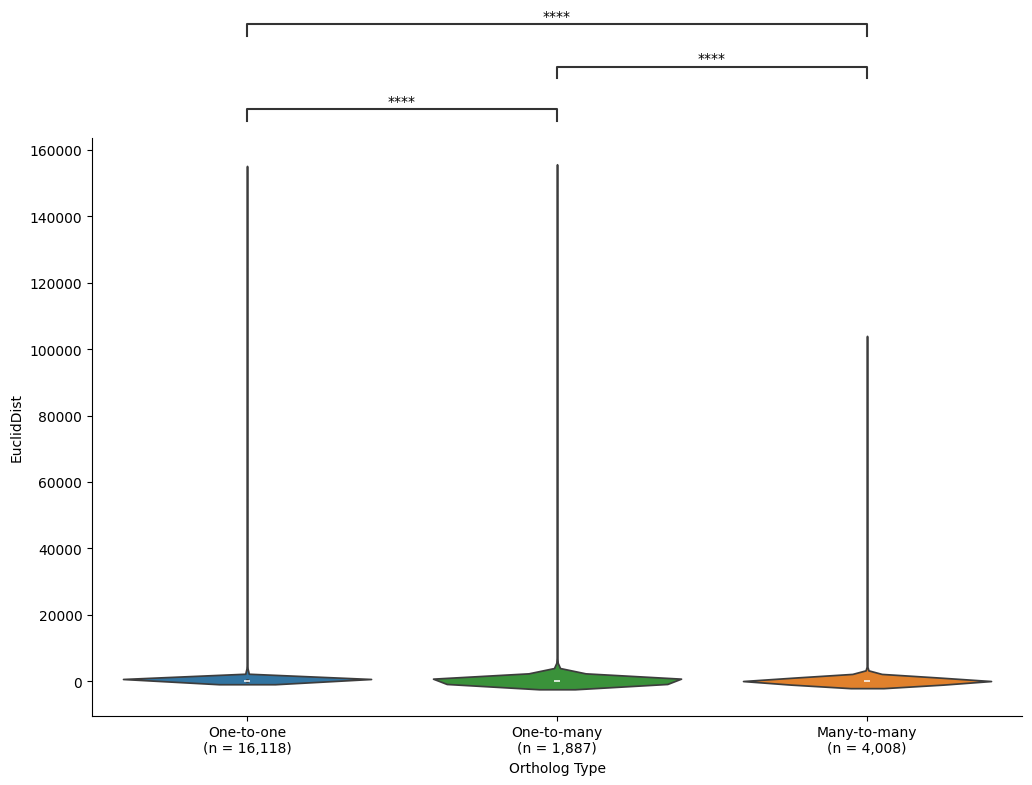

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:3.004e-57 U_stat=6.974e+06
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:5.572e-26 U_stat=5.405e+05
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:1.557e-179 U_stat=4.762e+06


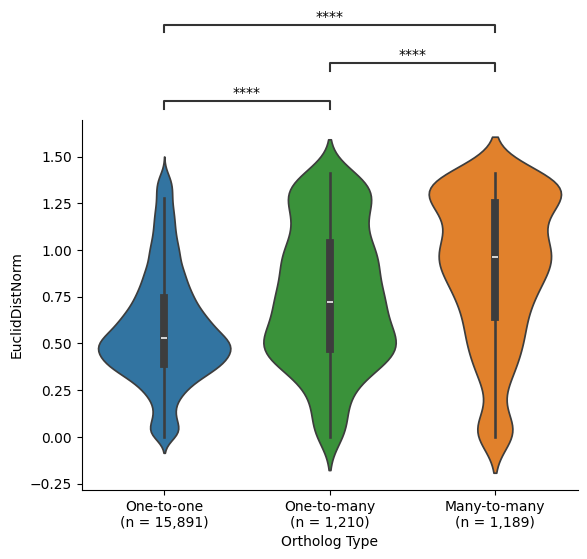

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:3.629e-25 U_stat=1.742e+07
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:8.135e-211 U_stat=5.670e+06
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=5.520e+07


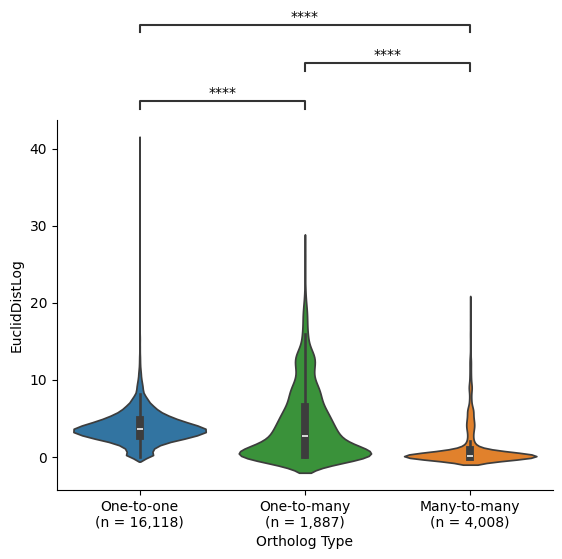

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:4.773e-40 U_stat=7.421e+06
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:4.366e-09 U_stat=6.198e+05
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:3.490e-87 U_stat=6.201e+06


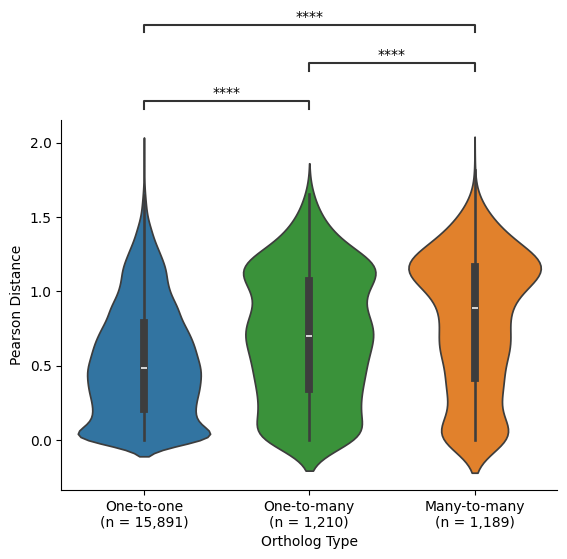

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:8.304e-37 U_stat=3.621e+06
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:1.965e-10 U_stat=1.051e+05
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:1.091e-78 U_stat=1.331e+06


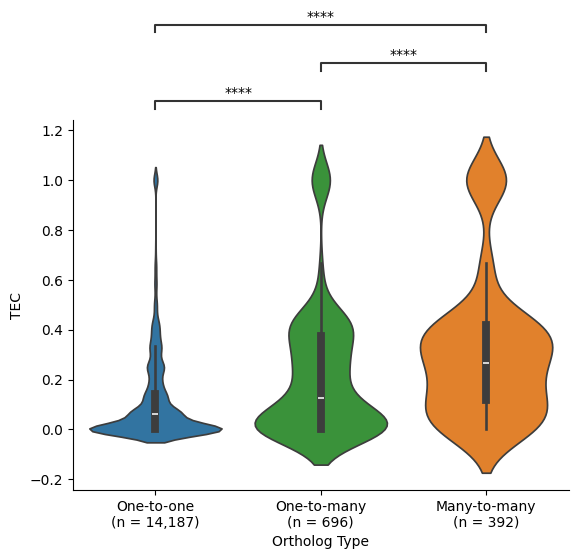

In [45]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
orthoTableHomology = orthoTable[orthoTable["Mouse homology type"].isin(["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"])]

sigTestPairs = [("ortholog_one2one", "ortholog_one2many"), ("ortholog_one2one", "ortholog_many2many"), ("ortholog_one2many", "ortholog_many2many")]
plt.figure(figsize=(12, 7.5))
for distMetric in orthoTableHomology.columns[4:9]:
    filteredDF = orthoTableHomology.dropna(subset=distMetric)
    ax = sns.violinplot(data=filteredDF, x="Mouse homology type", y=distMetric, hue="Mouse homology type", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], inner="box")
    # sns.striplot(data=filteredDF, x="Mouse homology type", y=distMetric, hue="Mouse homology type", size=2, alpha=0.25, order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], ax=ax)
    annotator = Annotator(ax, sigTestPairs, data=orthoTableHomology, x="Mouse homology type", y=distMetric, order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"])
    annotator.configure(test="Mann-Whitney", text_format="star", loc="outside")
    annotator.apply_and_annotate()
    ax.set_xlabel("Ortholog Type")
    if distMetric == "PearDist":
        ax.set_ylabel("Pearson Distance")
    ax.set_xticks([0, 1, 2], [f"One-to-one\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2one"].shape[0]:,})", f"One-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2many"].shape[0]:,})", f"Many-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_many2many"].shape[0]:,})"])
    sns.despine()
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/orthoCompare/violin{distMetric}.png", dpi=300, bbox_inches="tight")
    plt.show()


ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:3.004e-57 U_stat=6.974e+06
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:5.572e-26 U_stat=5.405e+05
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:1.557e-179 U_stat=4.762e+06
ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:1.524e-39 U_stat=5.992e+06
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:7.808e-23 U_stat=4.022e+05
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:2.351e-149 U_stat=4.200e+06
ortholog_one2one vs. ortholog_one2many: Mann-Whitney-Wilcoxon test two-sided, P_val:1.588e-35 U_stat=3.533e+06
ortholog_one2many vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:2.348e-21 U_stat=2.104e+05
ortholog_one2one vs. ortholog_many2many: Mann-Whitney-Wilcoxon test two-sided, P_val:4.796e-122 U_stat

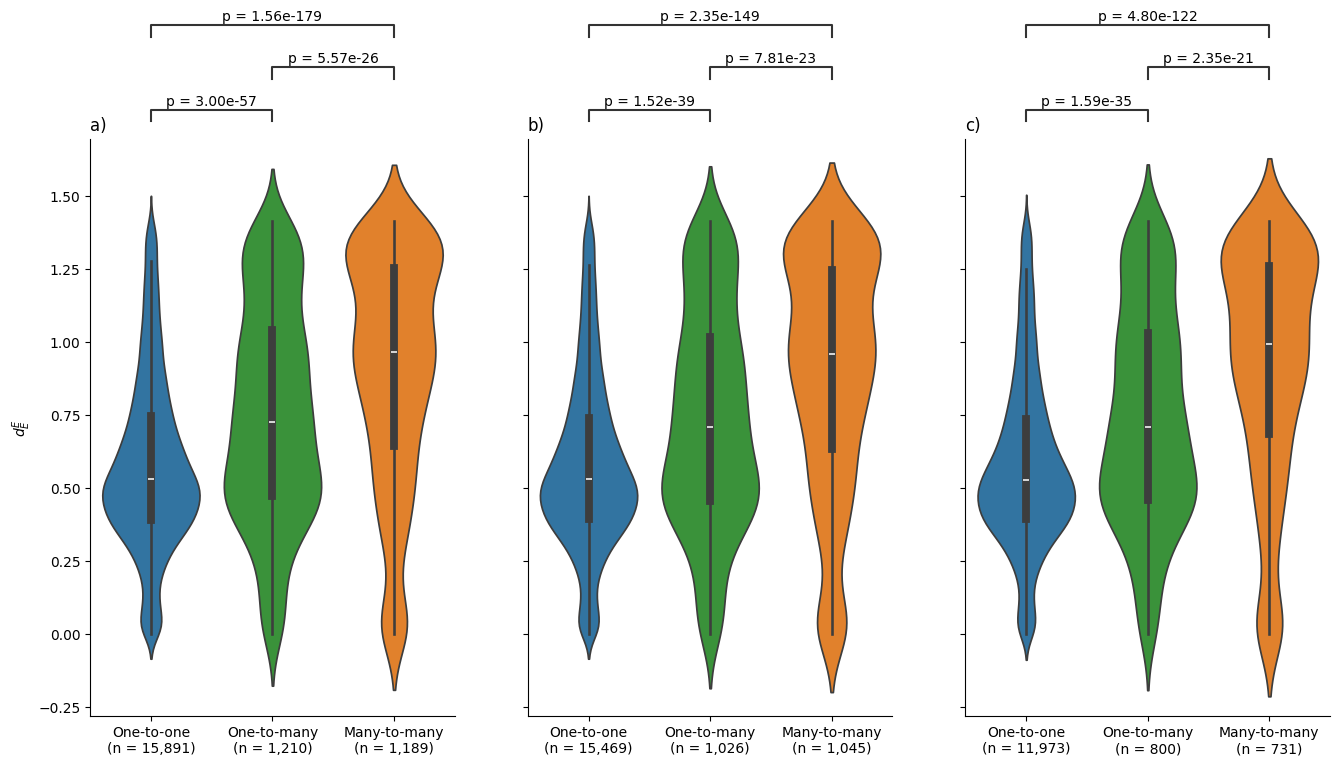

In [25]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
orthoTableHomology = orthoTable[orthoTable["Mouse homology type"].isin(["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"])]
orthoTableHomologyNoExon = orthoTableHomology[(orthoTableHomology["Number of Human Exons"] != 1) & (orthoTableHomology["Number of Mouse Exons"] != 1)]
orthoTableHomologyNoEnrichment = orthoTableHomology[orthoTableHomology["+/-"] == "nan"]
sigTestPairs = [("ortholog_one2one", "ortholog_one2many"), ("ortholog_one2one", "ortholog_many2many"), ("ortholog_one2many", "ortholog_many2many")]
fig, axes = plt.subplots(1, 3, figsize=(16, 7.5), sharey=True)

filteredDF = orthoTableHomology.dropna(subset="EuclidDistNorm")
sns.violinplot(data=filteredDF, x="Mouse homology type", y="EuclidDistNorm", hue="Mouse homology type", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], inner="box", ax=axes[0])
# sns.striplot(data=filteredDF, x="Mouse homology type", y="EuclidDistNorm", hue="Mouse homology type", size=2, alpha=0.25, order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], ax=ax)
annotator = Annotator(axes[0], sigTestPairs, data=orthoTableHomology, x="Mouse homology type", y="EuclidDistNorm", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"])
annotator.configure(test="Mann-Whitney", text_format="full", loc="outside", show_test_name=False, pvalue_format_string="{:.2e}", verbose=2)
annotator.apply_and_annotate()
axes[0].set_xlabel("")
axes[0].set_title("a)", loc="left")
axes[0].set_ylabel(r"$d_{E}^{E}$")
axes[0].set_xticks([0, 1, 2], [f"One-to-one\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2one"].shape[0]:,})", f"One-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2many"].shape[0]:,})", f"Many-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_many2many"].shape[0]:,})"])

filteredDF = orthoTableHomologyNoExon.dropna(subset="EuclidDistNorm")
sns.violinplot(data=filteredDF, x="Mouse homology type", y="EuclidDistNorm", hue="Mouse homology type", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], inner="box", ax=axes[1])
# sns.striplot(data=filteredDF, x="Mouse homology type", y="EuclidDistNorm", hue="Mouse homology type", size=2, alpha=0.25, order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], ax=ax)
annotator = Annotator(axes[1], sigTestPairs, data=orthoTableHomologyNoExon, x="Mouse homology type", y="EuclidDistNorm", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"])
annotator.configure(test="Mann-Whitney", text_format="full", loc="outside", show_test_name=False, pvalue_format_string="{:.2e}", verbose=2)
annotator.apply_and_annotate()
axes[1].set_xlabel("")
axes[1].set_title("b)", loc="left")
axes[1].set_xticks([0, 1, 2], [f"One-to-one\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2one"].shape[0]:,})", f"One-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2many"].shape[0]:,})", f"Many-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_many2many"].shape[0]:,})"])

filteredDF = orthoTableHomologyNoEnrichment.dropna(subset="EuclidDistNorm")
sns.violinplot(data=filteredDF, x="Mouse homology type", y="EuclidDistNorm", hue="Mouse homology type", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], inner="box", ax=axes[2])
# sns.striplot(data=filteredDF, x="Mouse homology type", y="EuclidDistNorm", hue="Mouse homology type", size=2, alpha=0.25, order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"], ax=ax)
annotator = Annotator(axes[2], sigTestPairs, data=orthoTableHomologyNoEnrichment, x="Mouse homology type", y="EuclidDistNorm", order=["ortholog_one2one", "ortholog_one2many", "ortholog_many2many"])
annotator.configure(test="Mann-Whitney", text_format="full", loc="outside", show_test_name=False, pvalue_format_string="{:.2e}", verbose=2)
annotator.apply_and_annotate()
axes[2].set_xlabel("")
axes[2].set_title("c)", loc="left")
axes[2].set_xticks([0, 1, 2], [f"One-to-one\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2one"].shape[0]:,})", f"One-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_one2many"].shape[0]:,})", f"Many-to-many\n(n = {filteredDF[filteredDF["Mouse homology type"] == "ortholog_many2many"].shape[0]:,})"])
sns.despine()
plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/noExonsvsNoEnrichment.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
orthoTableHomologyNoExon

,Gene stable ID,Mouse gene stable ID,Mouse homology type,Mouse Gene-order conservation score,EuclidDist,EuclidDistNorm,EuclidDistLog,PearDist,TEC,Num Human Dupes,...,Number of Mouse Exons,dN/dS,dN,dS,% Protein Identity,Human Tau,Mouse Tau,Human EB,Mouse EB,ModeEvol
0,ENSG00000065135,ENSMUSG00000000001,ortholog_one2one,100.0,197.746445,0.278561,6.701999,0.151442,0.000000,1.0,...,9,0.02836,0.0079,0.2774,98.305085,0.603618,0.582648,8.0,8.0,NaN
1,ENSG00000093009,ENSMUSG00000000028,ortholog_one2one,100.0,24.533616,1.024816,5.058507,1.001638,0.250000,1.0,...,25,0.08039,0.0414,0.5152,91.696113,0.745725,0.836247,3.0,6.0,NaN
2,ENSG00000102098,ENSMUSG00000000037,ortholog_one2one,100.0,2.084639,0.471628,1.444542,0.161786,0.166667,1.0,...,50,0.34796,0.2351,0.6757,66.666667,0.626336,0.769090,2.0,3.0,NaN
3,ENSG00000091583,ENSMUSG00000000049,ortholog_one2one,100.0,1776.546401,0.002316,2.516381,0.000003,0.500000,1.0,...,16,0.22115,0.1518,0.6863,76.521739,0.999408,0.999321,4.0,4.0,NaN
4,ENSG00000141562,ENSMUSG00000000056,ortholog_one2one,100.0,70.950296,0.525139,3.511421,0.661562,0.000000,1.0,...,16,0.12193,0.0844,0.6925,85.526316,0.255240,0.644225,8.0,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22459,ENSG00000289282,ENSMUSG00000144229,ortholog_one2many,100.0,NaN,NaN,NaN,NaN,NaN,2.0,...,5,0.42708,0.0142,0.0332,96.923077,NaN,NaN,0.0,0.0,NaN
22460,ENSG00000288645,ENSMUSG00000144230,ortholog_one2one,100.0,NaN,NaN,NaN,NaN,NaN,1.0,...,4,1.20441,0.0835,0.0693,84.375000,NaN,NaN,0.0,0.0,NaN
22466,ENSG00000255154,ENSMUSG00000144287,ortholog_one2one,100.0,NaN,NaN,NaN,NaN,NaN,1.0,...,5,0.26330,0.1292,0.4907,79.113924,0.381256,NaN,0.0,0.0,NaN
22467,ENSG00000229972,ENSMUSG00001074846,ortholog_one2one,100.0,NaN,NaN,NaN,NaN,NaN,1.0,...,18,0.36348,0.3637,1.0005,53.246753,0.663417,NaN,0.0,0.0,NaN


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Parent dN/dS vs. Daughter dN/dS: Wilcoxon test (paired samples), P_val:9.423e-04 Stat=1.870e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Parent dN/dS vs. Daughter dN/dS: Wilcoxon test (paired samples), P_val:3.087e-02 Stat=5.990e+02


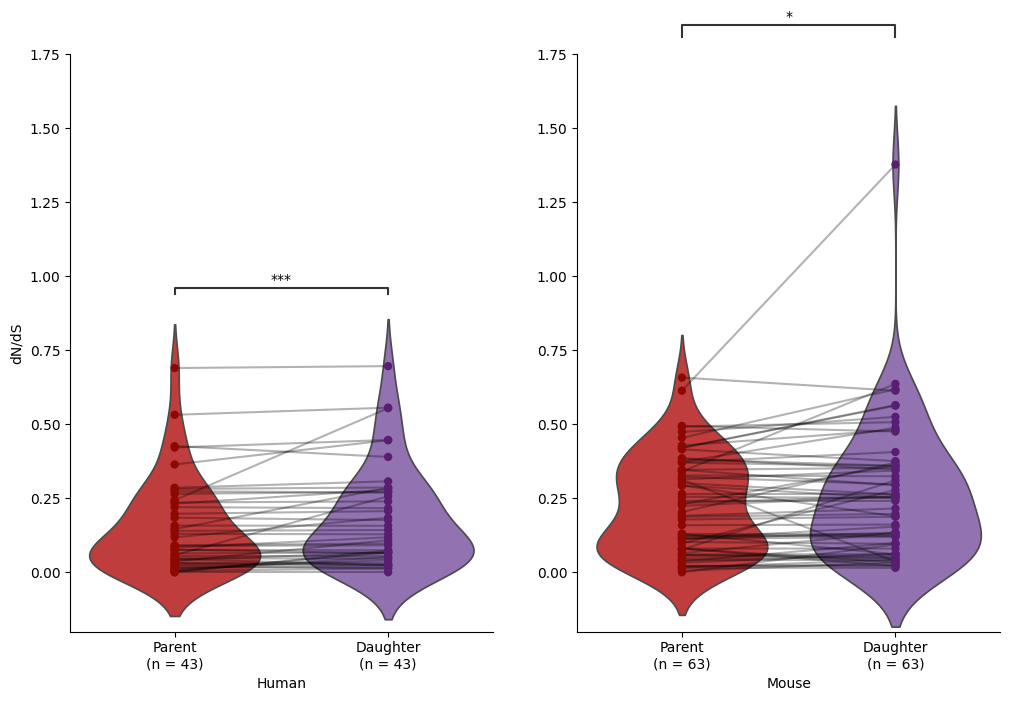

In [46]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
humanPD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet")
mousePD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet")

humanPD = humanPD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS"]], left_on=["Mouse Gene", "Human Parent"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "Parent dN/dS"})
humanPD = humanPD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS"]], left_on=["Mouse Gene", "Human Daughter"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "Daughter dN/dS"})

mousePD = mousePD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS"]], left_on=["Human Gene", "Mouse Parent"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "Parent dN/dS"})
mousePD = mousePD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS"]], left_on=["Human Gene", "Mouse Daughter"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "Daughter dN/dS"})

colors = list(sns.color_palette("tab10", 10))[3:5]
darkColors = list(sns.color_palette("dark"))[3:5]
fig, axes = plt.subplots(1, 2, figsize=(12, 7.5), sharey=True)
filteredHumanDF = humanPD.loc[:, ["Parent dN/dS", "Daughter dN/dS"]]
filteredHumanDF = filteredHumanDF[(filteredHumanDF["Parent dN/dS"].notna()) & (filteredHumanDF["Daughter dN/dS"].notna())]
filteredMouseDF = mousePD.loc[:, ["Parent dN/dS", "Daughter dN/dS"]]
filteredMouseDF = filteredMouseDF[(filteredMouseDF["Parent dN/dS"].notna()) & (filteredMouseDF["Daughter dN/dS"].notna())]

sns.violinplot(data=filteredHumanDF[["Parent dN/dS", "Daughter dN/dS"]], ax=axes[0], inner=None, palette=colors)
sns.stripplot(data=filteredHumanDF[["Parent dN/dS", "Daughter dN/dS"]], ax=axes[0], size=6, jitter=False, legend=False, palette=darkColors)
y_human = filteredHumanDF[["Parent dN/dS", "Daughter dN/dS"]].values.T
axes[0].plot([0, 1], y_human, color="black", alpha=0.3, zorder=1)
annotator = Annotator(axes[0], pairs=[("Parent dN/dS", "Daughter dN/dS")], data=filteredHumanDF[["Parent dN/dS", "Daughter dN/dS"]])
annotator.configure(test="Wilcoxon", text_format="star", loc="outside")
annotator.apply_and_annotate()
axes[0].set_ylim(-0.2, 1.75)
axes[0].set_ylabel("dN/dS")
axes[0].set_xlabel("Human")
axes[0].set_xticks([0, 1], [f"Parent\n(n = {filteredHumanDF["Parent dN/dS"].shape[0]})", f"Daughter\n(n = {filteredHumanDF["Daughter dN/dS"].shape[0]})"])

sns.violinplot(data=filteredMouseDF[["Parent dN/dS", "Daughter dN/dS"]], ax=axes[1], inner=None, palette=colors)
sns.stripplot(data=filteredMouseDF[["Parent dN/dS", "Daughter dN/dS"]], ax=axes[1], size=6, jitter=False, legend=False, palette=darkColors)
y_mouse = filteredMouseDF[["Parent dN/dS", "Daughter dN/dS"]].values.T
axes[1].plot([0, 1], y_mouse, color="black", alpha=0.3, zorder=1)
annotator = Annotator(axes[1], pairs=[("Parent dN/dS", "Daughter dN/dS")], data=filteredMouseDF[["Parent dN/dS", "Daughter dN/dS"]])
annotator.configure(test="Wilcoxon", text_format="star", loc="outside")
annotator.apply_and_annotate()
axes[1].set_ylim(-0.2, 1.75)
axes[1].set_xticks([0, 1], [f"Parent\n(n = {filteredMouseDF["Parent dN/dS"].shape[0]})", f"Daughter\n(n = {filteredMouseDF["Daughter dN/dS"].shape[0]})"])
axes[1].set_xlabel("Mouse")
axes[1].tick_params(axis="y", labelleft=True)

sns.despine()
plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/violin{"PvDdNdS"}.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
numHumanParent = (humanPD["Parent dN/dS"] > humanPD["Daughter dN/dS"]).sum()
numHumanDaughter = (humanPD["Parent dN/dS"] < humanPD["Daughter dN/dS"]).sum()
numMouseParent = (mousePD["Parent dN/dS"] > mousePD["Daughter dN/dS"]).sum()
numMouseDaughter = (mousePD["Parent dN/dS"] < mousePD["Daughter dN/dS"]).sum()

print(f"Human {stats.binomtest(numHumanDaughter, numHumanParent + numHumanDaughter, 0.5, alternative="greater")}")
print(f"Mouse {stats.binomtest(numMouseDaughter, numMouseParent + numMouseDaughter, 0.5, alternative="greater")}")

humanPD = humanPD[(humanPD["Parent dN/dS"].notna()) & (humanPD["Daughter dN/dS"].notna())]
mousePD = mousePD[(mousePD["Parent dN/dS"].notna()) & (mousePD["Daughter dN/dS"].notna())]
print(f"Human {stats.wilcoxon(filteredHumanDF["Daughter dN/dS"], filteredHumanDF["Parent dN/dS"], alternative="greater")}")
print(f"Mouse {stats.wilcoxon(filteredMouseDF["Daughter dN/dS"], filteredMouseDF["Parent dN/dS"], alternative="greater")}")


Human BinomTestResult(k=29, n=42, alternative='greater', statistic=0.6904761904761905, pvalue=0.009760236391230137)
Mouse BinomTestResult(k=38, n=59, alternative='greater', statistic=0.6440677966101694, pvalue=0.018171589978526942)
Human WilcoxonResult(statistic=np.float64(716.0), pvalue=np.float64(0.0004711358838938511))
Mouse WilcoxonResult(statistic=np.float64(1171.0), pvalue=np.float64(0.015435904285185185))


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

EuclidDist Parent vs. EuclidDist Daughter: Wilcoxon test (paired samples), P_val:3.523e-02 Stat=2.990e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

EuclidDist Parent vs. EuclidDist Daughter: Wilcoxon test (paired samples), P_val:1.030e-01 Stat=8.230e+02


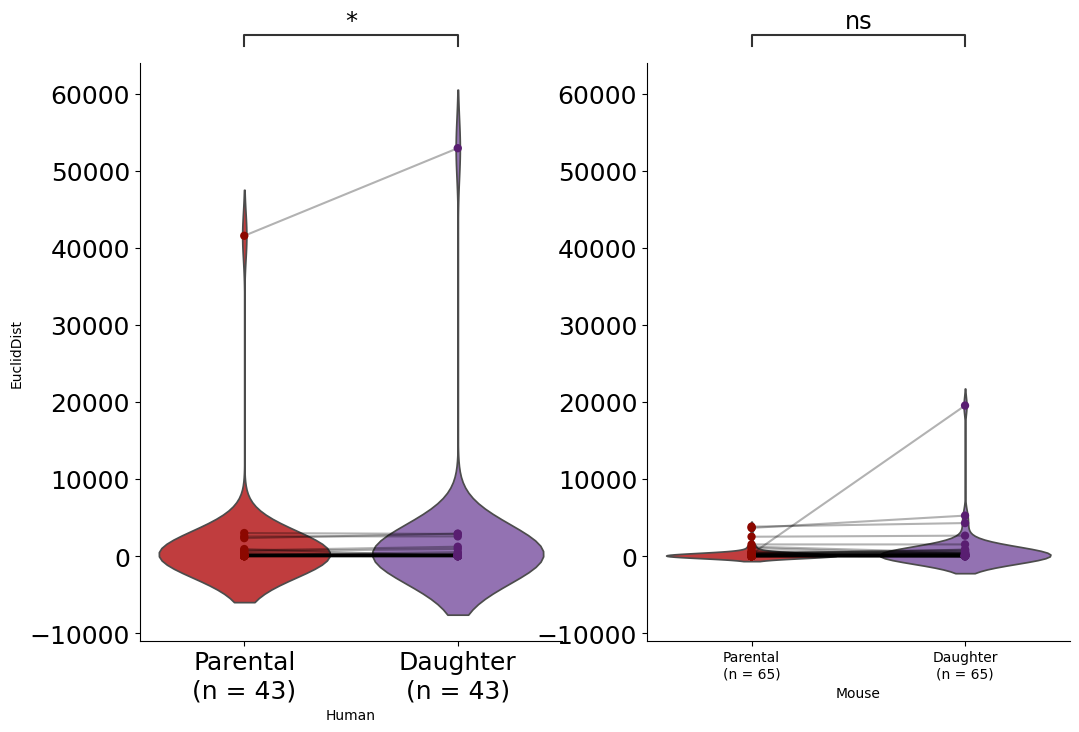

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

EuclidDistNorm Parent vs. EuclidDistNorm Daughter: Wilcoxon test (paired samples), P_val:3.154e-03 Stat=2.330e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

EuclidDistNorm Parent vs. EuclidDistNorm Daughter: Wilcoxon test (paired samples), P_val:5.665e-04 Stat=5.450e+02


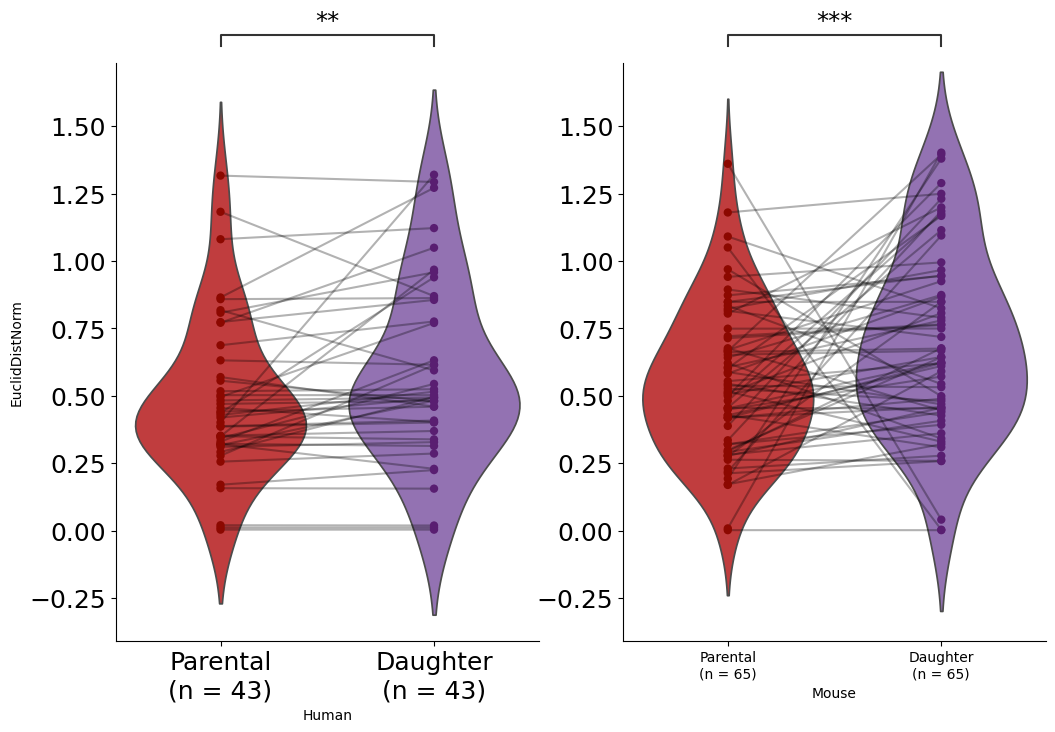

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

EuclidDistLog Parent vs. EuclidDistLog Daughter: Wilcoxon test (paired samples), P_val:1.295e-02 Stat=2.690e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

EuclidDistLog Parent vs. EuclidDistLog Daughter: Wilcoxon test (paired samples), P_val:9.777e-04 Stat=5.680e+02


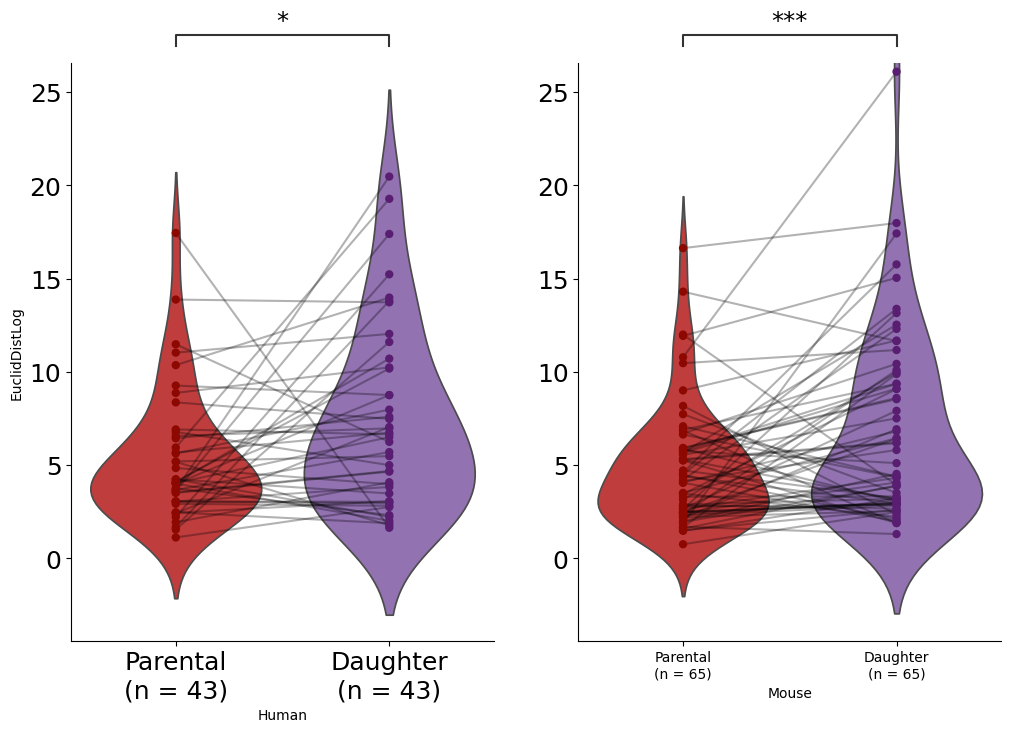

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PearDist Parent vs. PearDist Daughter: Wilcoxon test (paired samples), P_val:5.624e-03 Stat=2.470e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PearDist Parent vs. PearDist Daughter: Wilcoxon test (paired samples), P_val:3.309e-03 Stat=6.230e+02


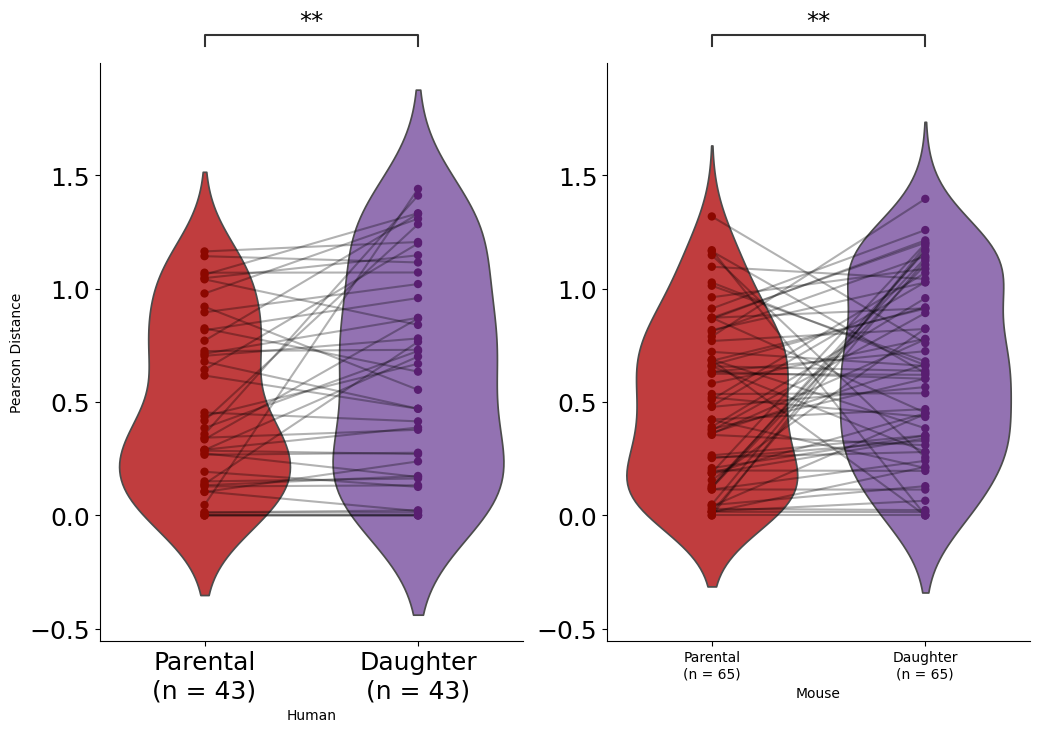

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

TEC Parent vs. TEC Daughter: Wilcoxon test (paired samples), P_val:8.576e-04 Stat=3.350e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

TEC Parent vs. TEC Daughter: Wilcoxon test (paired samples), P_val:2.757e-04 Stat=3.205e+02


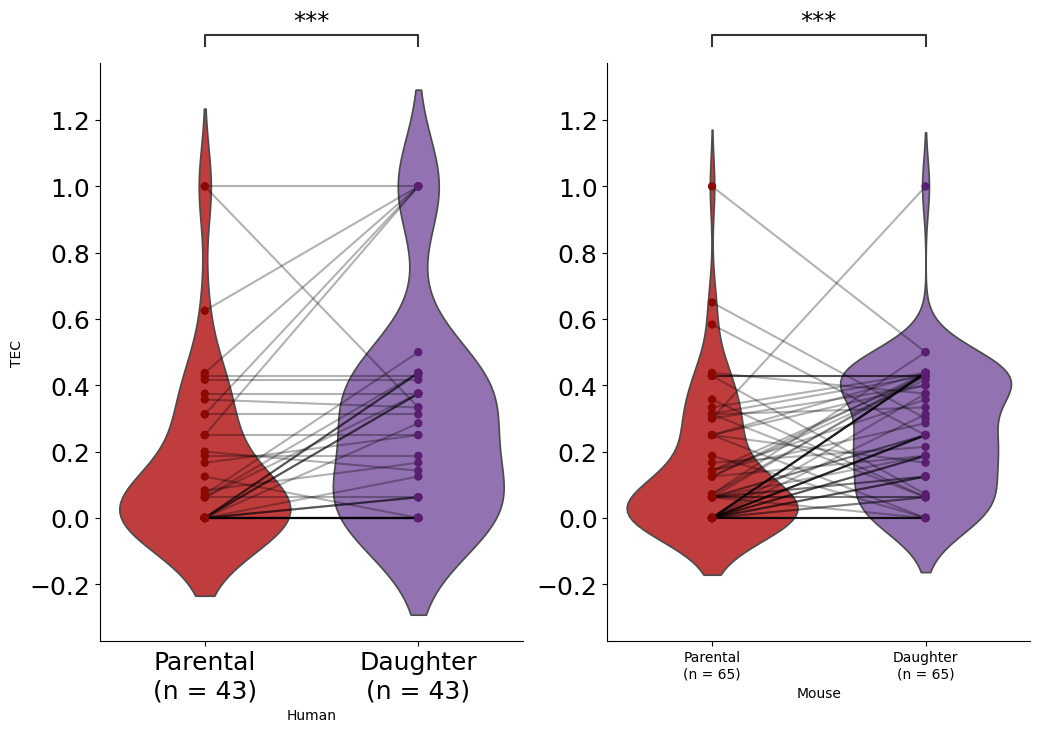

In [9]:
humanPD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet")
mousePD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet")

colors = list(sns.color_palette("tab10", 10))[3:5]
darkColors = list(sns.color_palette("dark"))[3:5]
for distMetricIdx in range(5, 15, 2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 7.5), sharey=True)
    filteredHumanDF = humanPD.iloc[:, distMetricIdx: distMetricIdx + 2]
    filteredMouseDF = mousePD.iloc[:, distMetricIdx: distMetricIdx + 2]
    col1 = humanPD.columns[distMetricIdx]
    col2 = humanPD.columns[distMetricIdx + 1]

    sns.violinplot(data=filteredHumanDF[[col1, col2]], ax=axes[0], inner=None, palette=colors)
    sns.stripplot(data=filteredHumanDF[[col1, col2]], ax=axes[0], size=6, jitter=False, legend=False, palette=darkColors)
    y_human = filteredHumanDF[[col1, col2]].values.T
    axes[0].plot([0, 1], y_human, color="black", alpha=0.3, zorder=1)
    annotator = Annotator(axes[0], pairs=[(col1, col2)], data=filteredHumanDF[[col1, col2]], )
    annotator.configure(test="Wilcoxon", text_format="star", loc="outside", fontsize="xx-large")
    annotator.apply_and_annotate()
    axes[0].set_ylabel(col1.replace(" Parent", ""))
    axes[0].set_xticks([0, 1], [f"Parental\n(n = {filteredHumanDF[col1].shape[0]})", f"Daughter\n(n = {filteredHumanDF[col2].shape[0]})"])
    if distMetricIdx == 11:
        axes[0].set_ylabel("Pearson Distance")
    axes[0].set_xlabel("Human")
    axes[0].tick_params(labelsize=18)

    sns.violinplot(data=filteredMouseDF[[col1, col2]], ax=axes[1], inner=None, palette=colors)
    sns.stripplot(data=filteredMouseDF[[col1, col2]], ax=axes[1], size=6, jitter=False, legend=False, palette=darkColors)
    y_mouse = filteredMouseDF[[col1, col2]].values.T
    axes[1].plot([0, 1], y_mouse, color="black", alpha=0.3, zorder=1)
    annotator = Annotator(axes[1], pairs=[(col1, col2)], data=filteredMouseDF[[col1, col2]])
    annotator.configure(test="Wilcoxon", text_format="star", loc="outside", fontsize="xx-large")
    annotator.apply_and_annotate()
    axes[1].set_xticks([0, 1], [f"Parental\n(n = {filteredMouseDF[col1].shape[0]})", f"Daughter\n(n = {filteredMouseDF[col2].shape[0]})"])
    axes[1].set_xlabel("Mouse")
    axes[1].tick_params(axis="y", labelleft=True, labelsize=18)

    sns.despine()
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/parentDaughterCompare/violin{col1.replace(" Parent", "")}.png", dpi=300, bbox_inches="tight")
    plt.show()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:9.117e-03 U_stat=3.840e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:5.054e-02 U_stat=1.930e+03
75.0 vs. 50.0: Mann-Whitney-Wilcoxon test two-sided, P_val:9.018e-01 U_stat=9.820e+02
100.0 vs. 75.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.262e-01 U_stat=1.819e+03
100.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:1.399e-01 U_stat=1.407e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:6.662e-09 U_stat=2.785e+04
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.284e-02 U_stat=1.620e+04
75.0 vs. 50.0: 

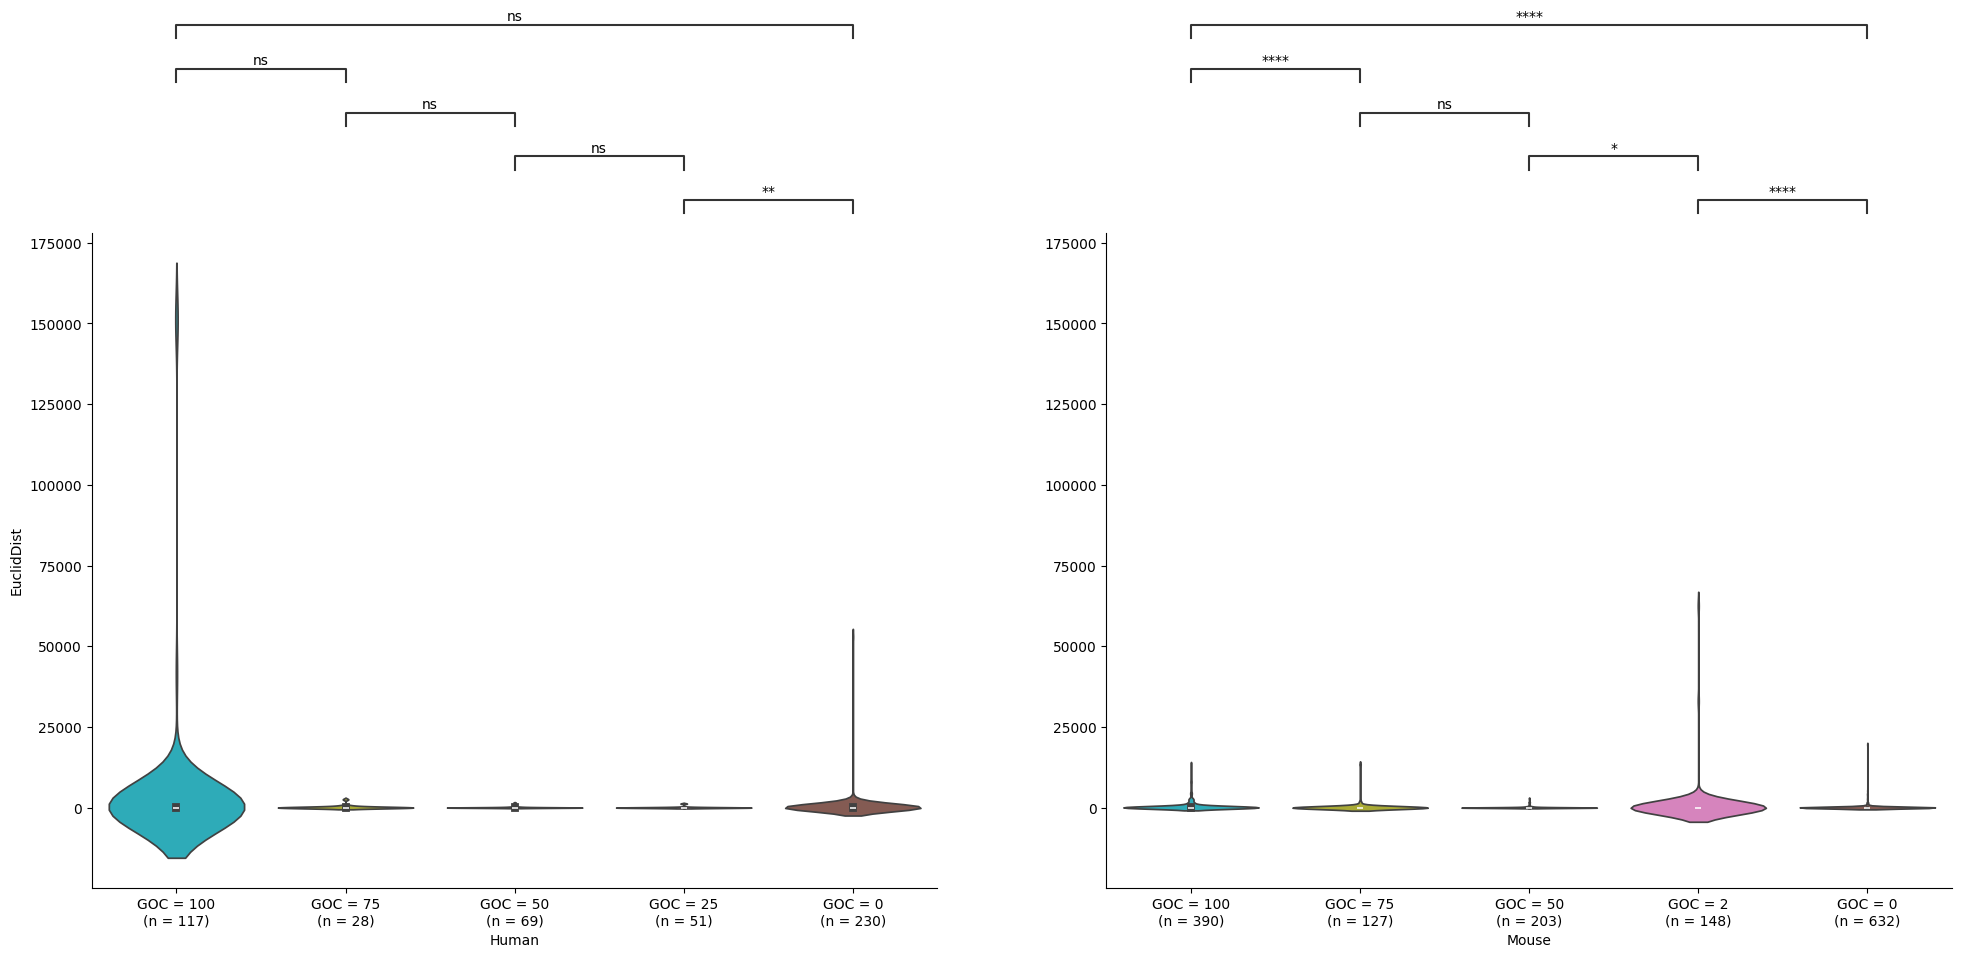

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:9.104e-01 U_stat=3.370e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:1.723e-01 U_stat=9.770e+02
75.0 vs. 50.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.442e-01 U_stat=7.070e+02
100.0 vs. 75.0: Mann-Whitney-Wilcoxon test two-sided, P_val:4.217e-01 U_stat=1.490e+03
100.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:6.532e-02 U_stat=8.700e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.323e-01 U_stat=6.635e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.325e-01 U_stat=3.208e+03
75.0 vs. 50.0: 

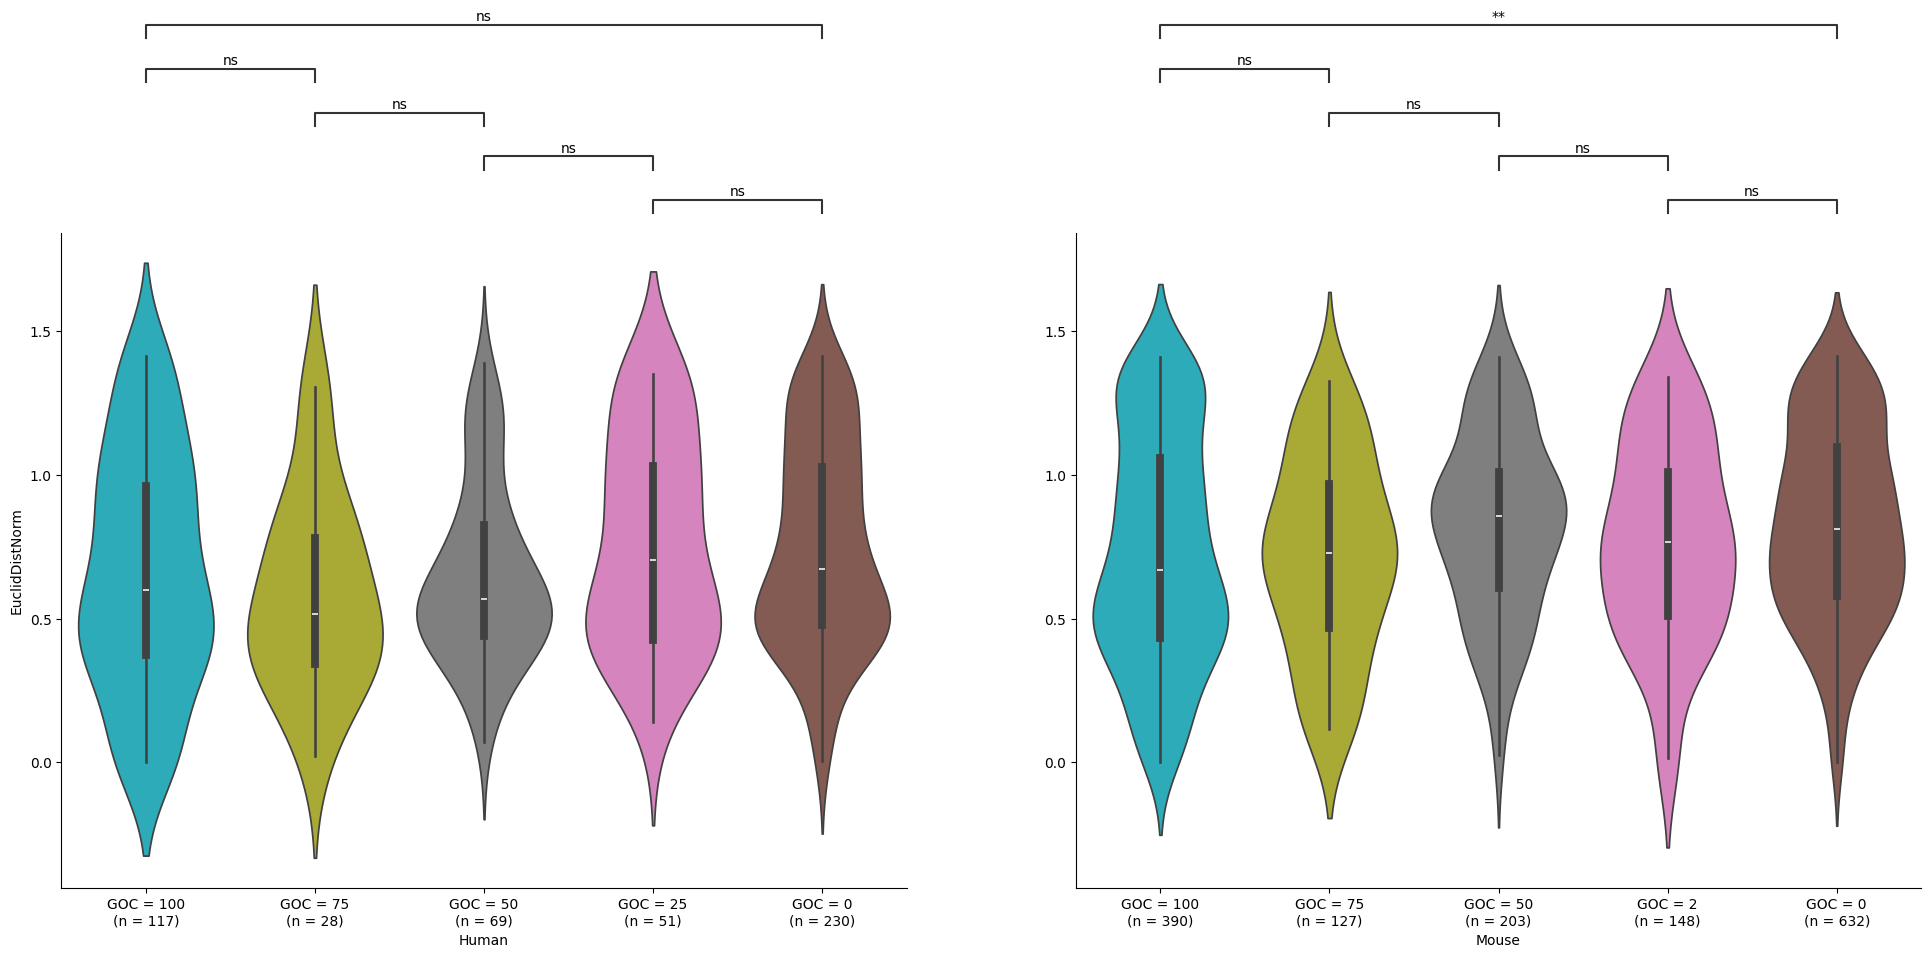

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:1.161e-02 U_stat=3.880e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:1.527e-01 U_stat=1.838e+03
75.0 vs. 50.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.216e-01 U_stat=8.410e+02
100.0 vs. 75.0: Mann-Whitney-Wilcoxon test two-sided, P_val:5.909e-01 U_stat=1.731e+03
100.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.197e-02 U_stat=1.100e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:1.150e-09 U_stat=2.722e+04
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.638e-02 U_stat=1.615e+04
75.0 vs. 50.0: 

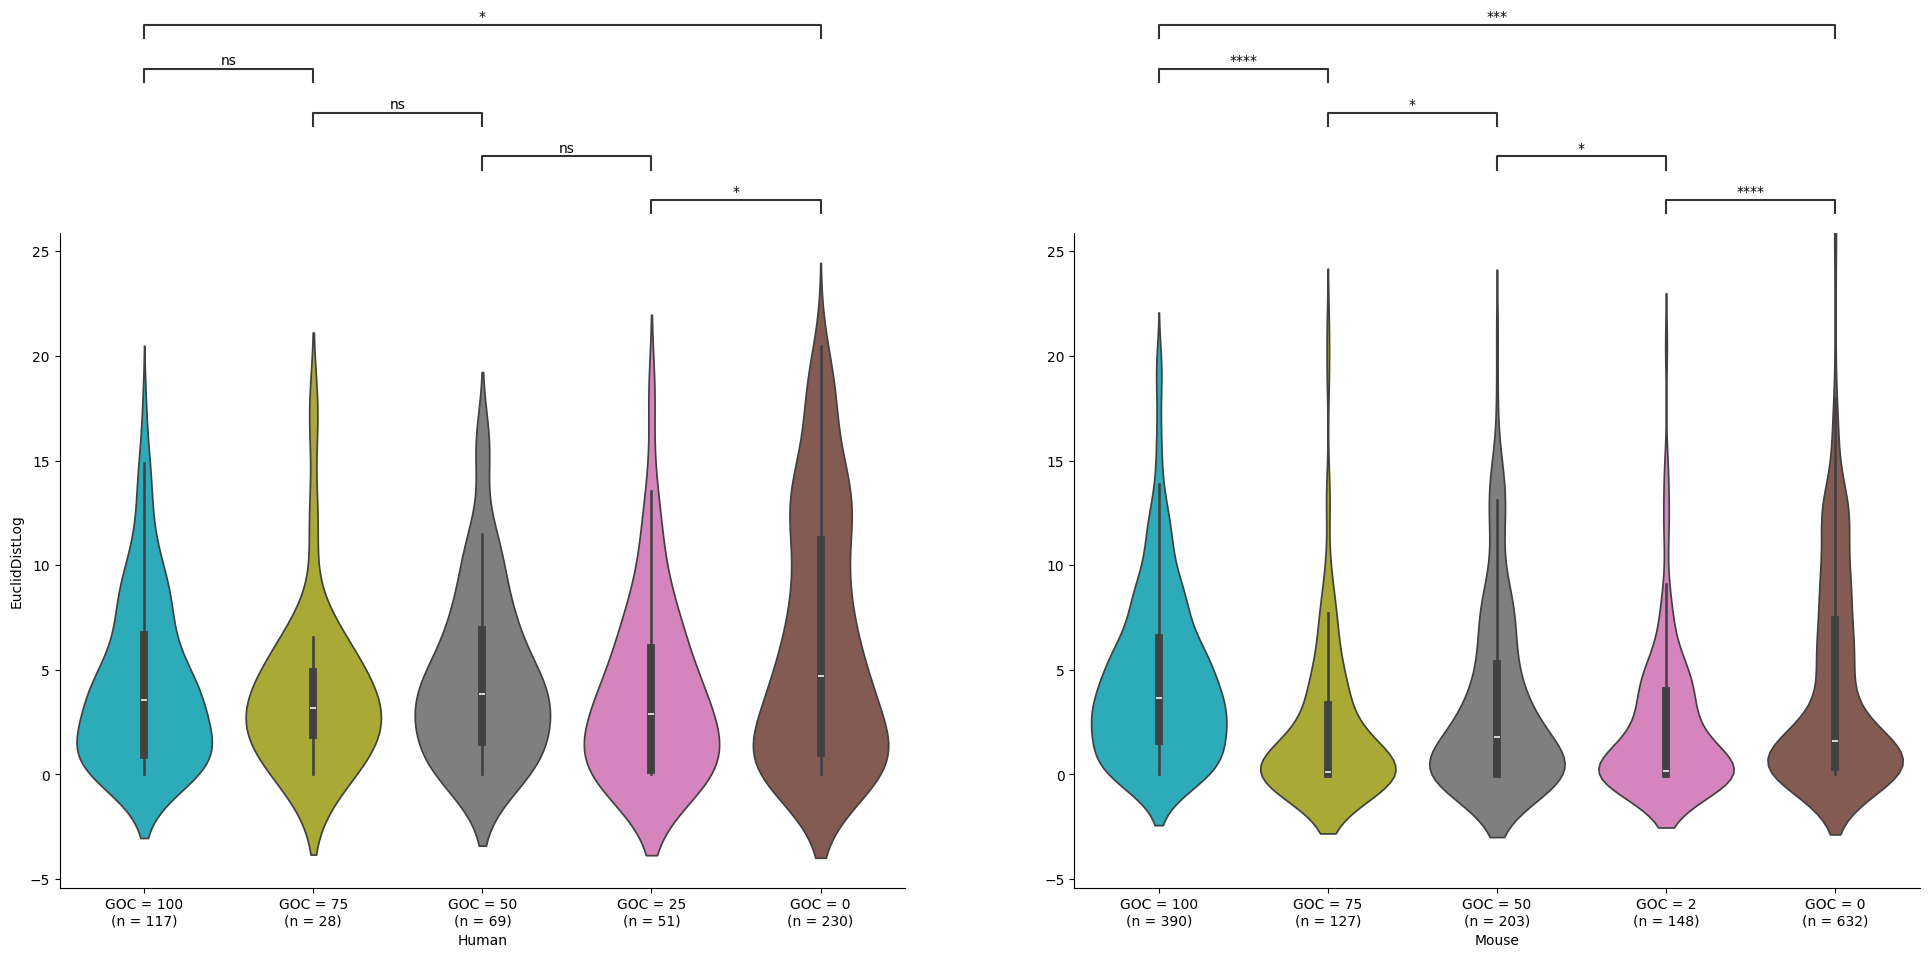

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:7.768e-01 U_stat=3.230e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.267e-01 U_stat=9.990e+02
75.0 vs. 50.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.629e-01 U_stat=7.110e+02
100.0 vs. 75.0: Mann-Whitney-Wilcoxon test two-sided, P_val:7.232e-01 U_stat=1.412e+03
100.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.261e-03 U_stat=7.853e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:3.707e-01 U_stat=6.822e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:5.494e-01 U_stat=3.104e+03
75.0 vs. 50.0: 

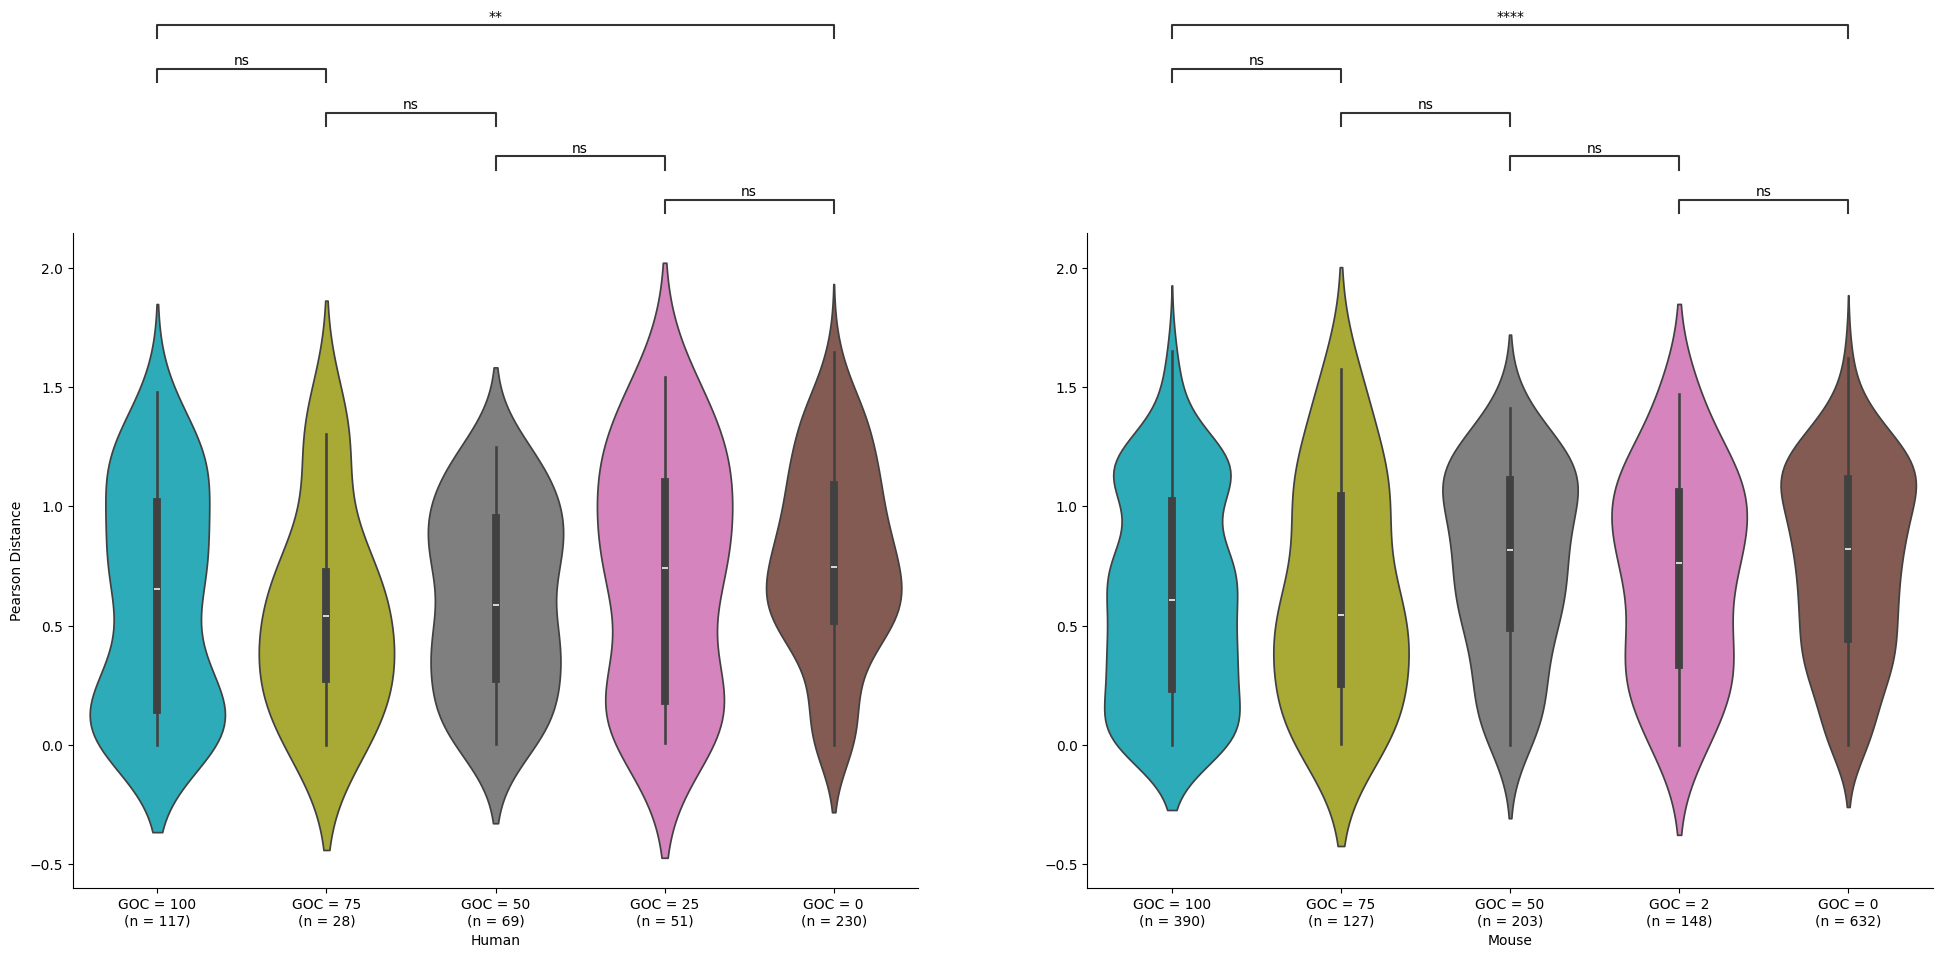

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.849e-01 U_stat=7.200e+02
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:4.191e-01 U_stat=3.280e+02
75.0 vs. 50.0: Mann-Whitney-Wilcoxon test two-sided, P_val:9.282e-02 U_stat=2.930e+02
100.0 vs. 75.0: Mann-Whitney-Wilcoxon test two-sided, P_val:7.641e-01 U_stat=6.840e+02
100.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.030e-01 U_stat=2.096e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

25.0 vs. 0.0: Mann-Whitney-Wilcoxon test two-sided, P_val:2.952e-01 U_stat=1.702e+03
50.0 vs. 25.0: Mann-Whitney-Wilcoxon test two-sided, P_val:8.600e-01 U_stat=1.190e+03
75.0 vs. 50.0: 

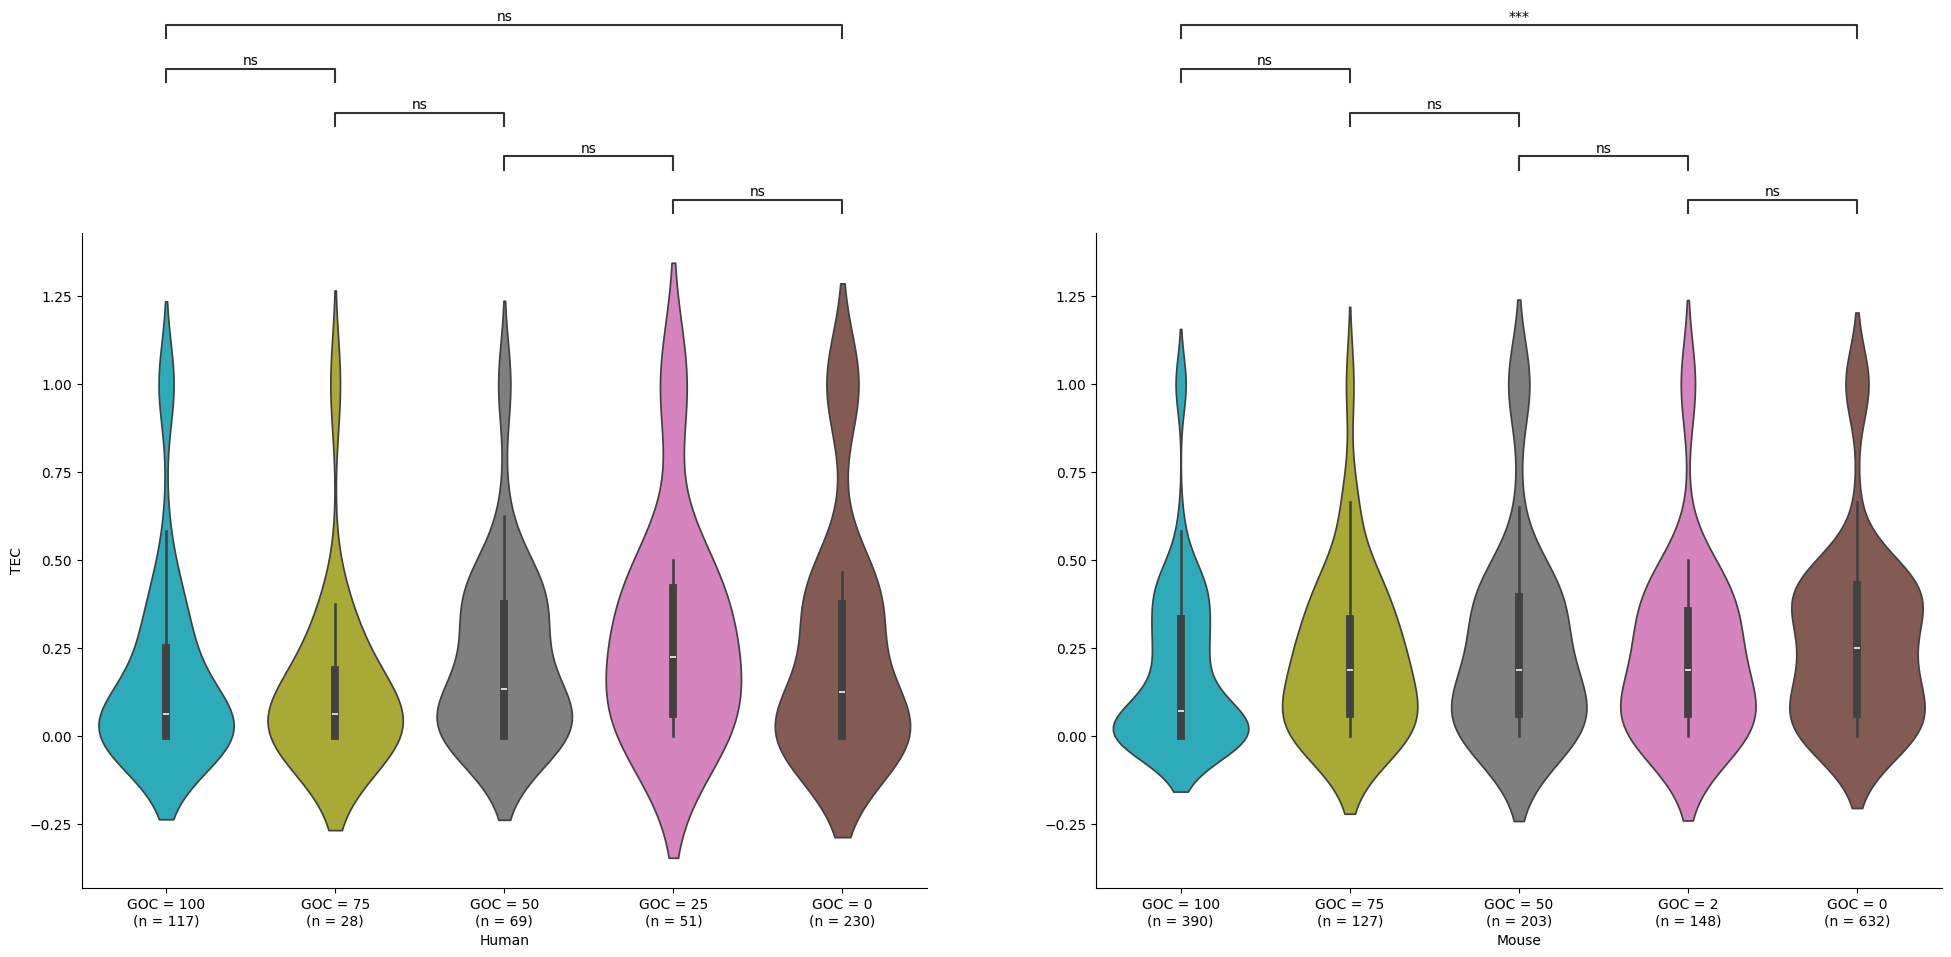

In [49]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
gocScoreChoices = [100.0, 75.0, 50.0, 25.0, 0.0]
testPairs = [(0.0, 25.0), (25.0, 50.0), (50.0, 75.0), (75.0, 100.0), (0.0, 100.0)]
orthoTableOne2Many = orthoTable[orthoTable["Mouse homology type"] == "ortholog_one2many"]

colors = list(sns.color_palette("tab10", 10))[5:10]
for distMetric in orthoTableOne2Many.columns[4:9]:
    fig, axes = plt.subplots(1, 2, figsize=(24, 8.5), sharey=True)
    filteredHumanDF = orthoTableOne2Many[(orthoTableOne2Many["Duplicated Species"] == "Human")]
    filteredMouseDF = orthoTableOne2Many[(orthoTableOne2Many["Duplicated Species"] == "Mouse")]
    sns.violinplot(data=filteredHumanDF, x="Mouse Gene-order conservation score", y=distMetric, hue="Mouse Gene-order conservation score", order=gocScoreChoices, legend=False, ax=axes[0], palette=colors)
    annotator = Annotator(axes[0], pairs=testPairs, x="Mouse Gene-order conservation score", y=distMetric, data=filteredHumanDF, order=gocScoreChoices)
    annotator.configure(test="Mann-Whitney", text_format="star", loc="outside")
    annotator.apply_and_annotate()
    axes[0].set_xticks([0, 1, 2, 3, 4], [f"GOC = 100\n(n = {filteredHumanDF[filteredHumanDF["Mouse Gene-order conservation score"] == 100].shape[0]})",
                                  f"GOC = 75\n(n = {filteredHumanDF[filteredHumanDF["Mouse Gene-order conservation score"] == 75].shape[0]})",
                                  f"GOC = 50\n(n = {filteredHumanDF[filteredHumanDF["Mouse Gene-order conservation score"] == 50].shape[0]})",
                                  f"GOC = 25\n(n = {filteredHumanDF[filteredHumanDF["Mouse Gene-order conservation score"] == 25].shape[0]})",
                                  f"GOC = 0\n(n = {filteredHumanDF[filteredHumanDF["Mouse Gene-order conservation score"] == 0].shape[0]})"])
    if distMetric == "PearDist":
        axes[0].set_ylabel("Pearson Distance")
    axes[0].set_xlabel("Human")

    sns.violinplot(data=filteredMouseDF, x="Mouse Gene-order conservation score", y=distMetric, hue="Mouse Gene-order conservation score", order=gocScoreChoices, legend=False, ax=axes[1], palette=colors)
    annotator = Annotator(axes[1], pairs=testPairs, x="Mouse Gene-order conservation score", y=distMetric, data=filteredMouseDF, order=gocScoreChoices)
    annotator.configure(test="Mann-Whitney", text_format="star", loc="outside")
    annotator.apply_and_annotate()
    axes[1].set_xticks([0, 1, 2, 3, 4], [f"GOC = 100\n(n = {filteredMouseDF[filteredMouseDF["Mouse Gene-order conservation score"] == 100].shape[0]})",
                                  f"GOC = 75\n(n = {filteredMouseDF[filteredMouseDF["Mouse Gene-order conservation score"] == 75].shape[0]})",
                                  f"GOC = 50\n(n = {filteredMouseDF[filteredMouseDF["Mouse Gene-order conservation score"] == 50].shape[0]})",
                                  f"GOC = 2\n(n = {filteredMouseDF[filteredMouseDF["Mouse Gene-order conservation score"] == 25].shape[0]})",
                                  f"GOC = 0\n(n = {filteredMouseDF[filteredMouseDF["Mouse Gene-order conservation score"] == 0].shape[0]})"])
    axes[1].set_xlabel("Mouse")
    axes[1].set_ylabel("")
    axes[1].tick_params(axis="y", labelleft=True)
    sns.despine()
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/GOCCompare/violinCompareGOC{distMetric}.png", dpi=300, bbox_inches="tight")
    plt.show()

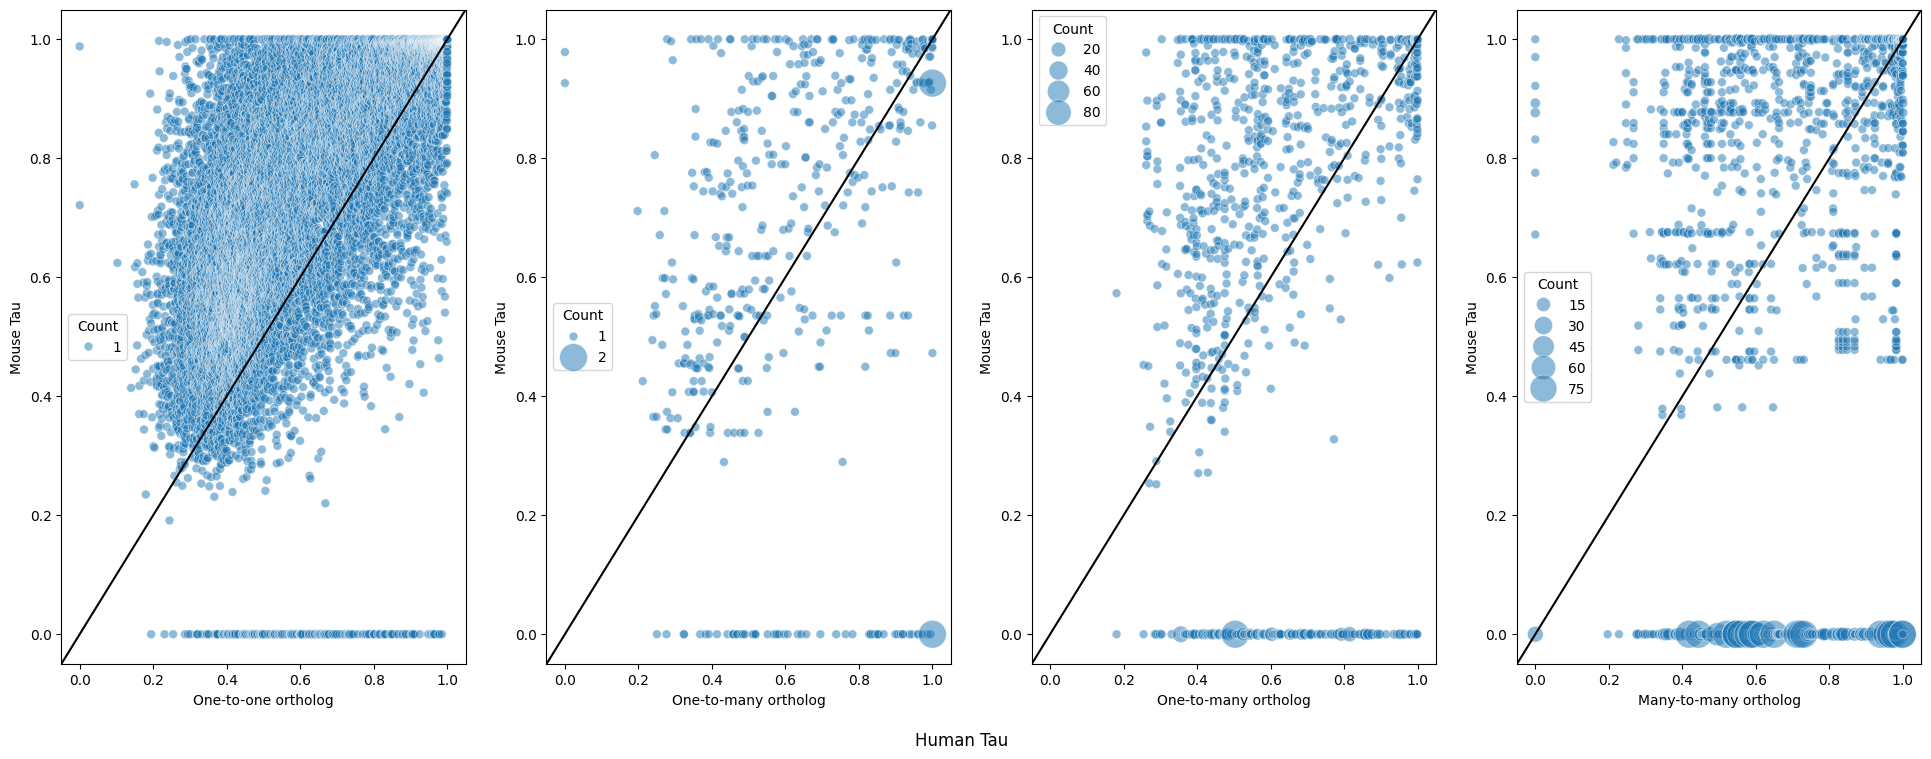

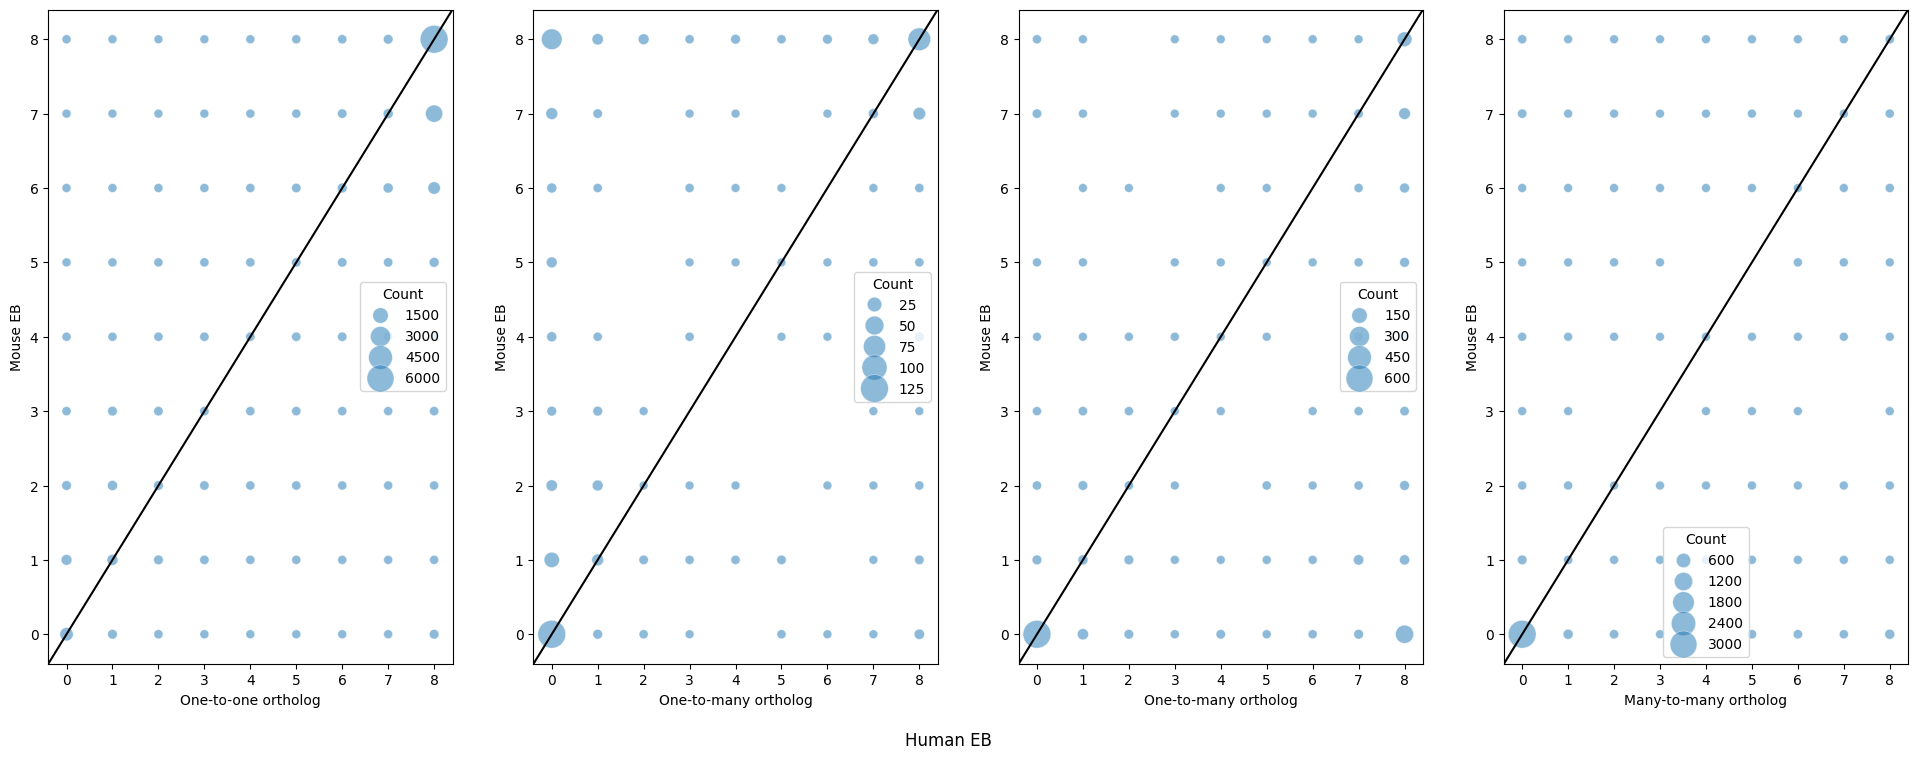

In [ ]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")
translationTable = {
    "ortholog_one2one": "ortholog_one2one",
    "ortholog_one2many": "ortholog_one2many",
    "ortholog_many2many": "ortholog_many2many",
    "duplicated in human": "Human",
    "duplicated in mouse": "Mouse"
}
orthoTranslationTable = {
    "ortholog_one2one": "One-to-one ortholog",
    "ortholog_one2many, duplicated in human": "One-to-many ortholog, duplicated in human",
    "ortholog_one2many, duplicated in mouse": "One-to-many ortholog, duplicated in mouse",
    "ortholog_many2many": "Many-to-many ortholog",
}
binomDF = pd.DataFrame(
    index = ["ortholog_one2one", "ortholog_one2many, duplicated in human", "ortholog_one2many, duplicated in mouse", "ortholog_many2many"],
    columns = ["numAboveLine", "numBelowLine", "totalNum", "pValue"]
)

for metric in ["Tau", "EB"]:
    fig, axes = plt.subplots(1, 4, figsize=(24, 8.5))
    dfValues = binomDF.to_dict(orient="index")
    for idx, category in enumerate(["ortholog_one2one", "ortholog_one2many, duplicated in human", "ortholog_one2many, duplicated in mouse", "ortholog_many2many"]):
        fileName = None
        translatedCategory = list(map(translationTable.get, category.split(", ")))
        if len(translatedCategory) == 1:
            filteredDF = orthoTable[orthoTable["Mouse homology type"] == translatedCategory[0]]
            fileName = f"/Users/andrewhsu/Projects/McNair/plots/species{metric}Corr/{translatedCategory[0]}.png"
        elif len(translatedCategory) == 2:
            filteredDF = orthoTable[(orthoTable["Mouse homology type"] == translatedCategory[0]) & (orthoTable["Duplicated Species"] == translatedCategory[1])]
            fileName = f"/Users/andrewhsu/Projects/McNair/plots/species{metric}Corr/{translatedCategory[0]}DupedIn{translatedCategory[1]}.png"
        filteredDFNA = filteredDF.dropna(subset=[f"Human {metric}", f"Mouse {metric}"])

        numAboveLine = (filteredDFNA[f"Mouse {metric}"] > filteredDFNA[f"Human {metric}"]).sum()
        numBelowLine = (filteredDFNA[f"Mouse {metric}"] < filteredDFNA[f"Human {metric}"]).sum()
        totalNum = filteredDFNA[f"Mouse {metric}"].shape[0]
        res = stats.binomtest(numAboveLine, numAboveLine + numBelowLine, p=0.5)

        dfValues[category]["numAboveLine"] = numAboveLine
        dfValues[category]["numBelowLine"] = numBelowLine
        dfValues[category]["totalNum"] = totalNum 
        dfValues[category]["pValue"] = res.pvalue

        xyCounts = filteredDFNA.groupby([f"Human {metric}", f"Mouse {metric}"]).size().reset_index(name="Count")
        ax = sns.scatterplot(data=xyCounts, x=f"Human {metric}", y=f"Mouse {metric}", size="Count", sizes=(40, 400), alpha=0.5, legend="brief", ax=axes[idx])
        ax.axline((0, 0), slope=1, color="black", linewidth=1.5)
        ax.set_xlabel(orthoTranslationTable[translatedCategory[0]])
    fig.supxlabel(f"Human {metric}")
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/species{metric}Corr.png", dpi=300)
    plt.show()
    plt.close()

    with pd.ExcelWriter(f"/Users/andrewhsu/Projects/McNair/data/species{metric}Binom.xlsx") as w:
        pd.DataFrame(dfValues).T.to_excel(w, sheet_name="Sheet1", index=True)



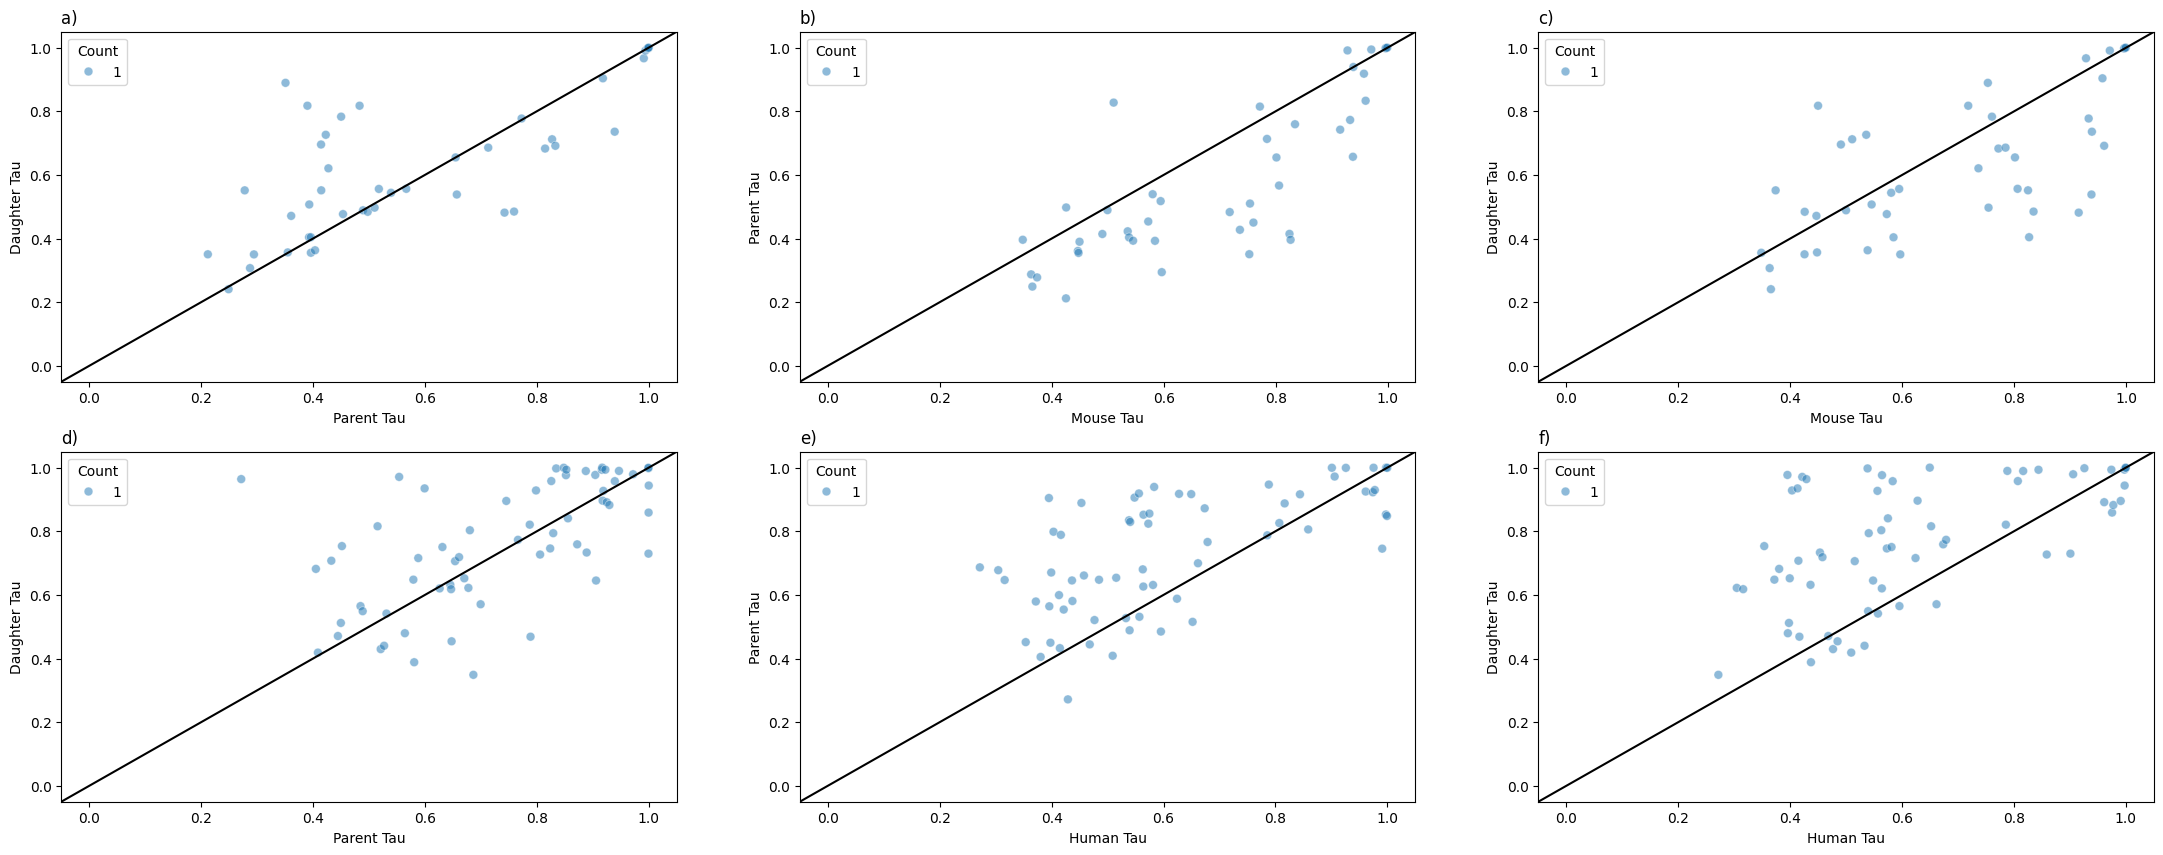

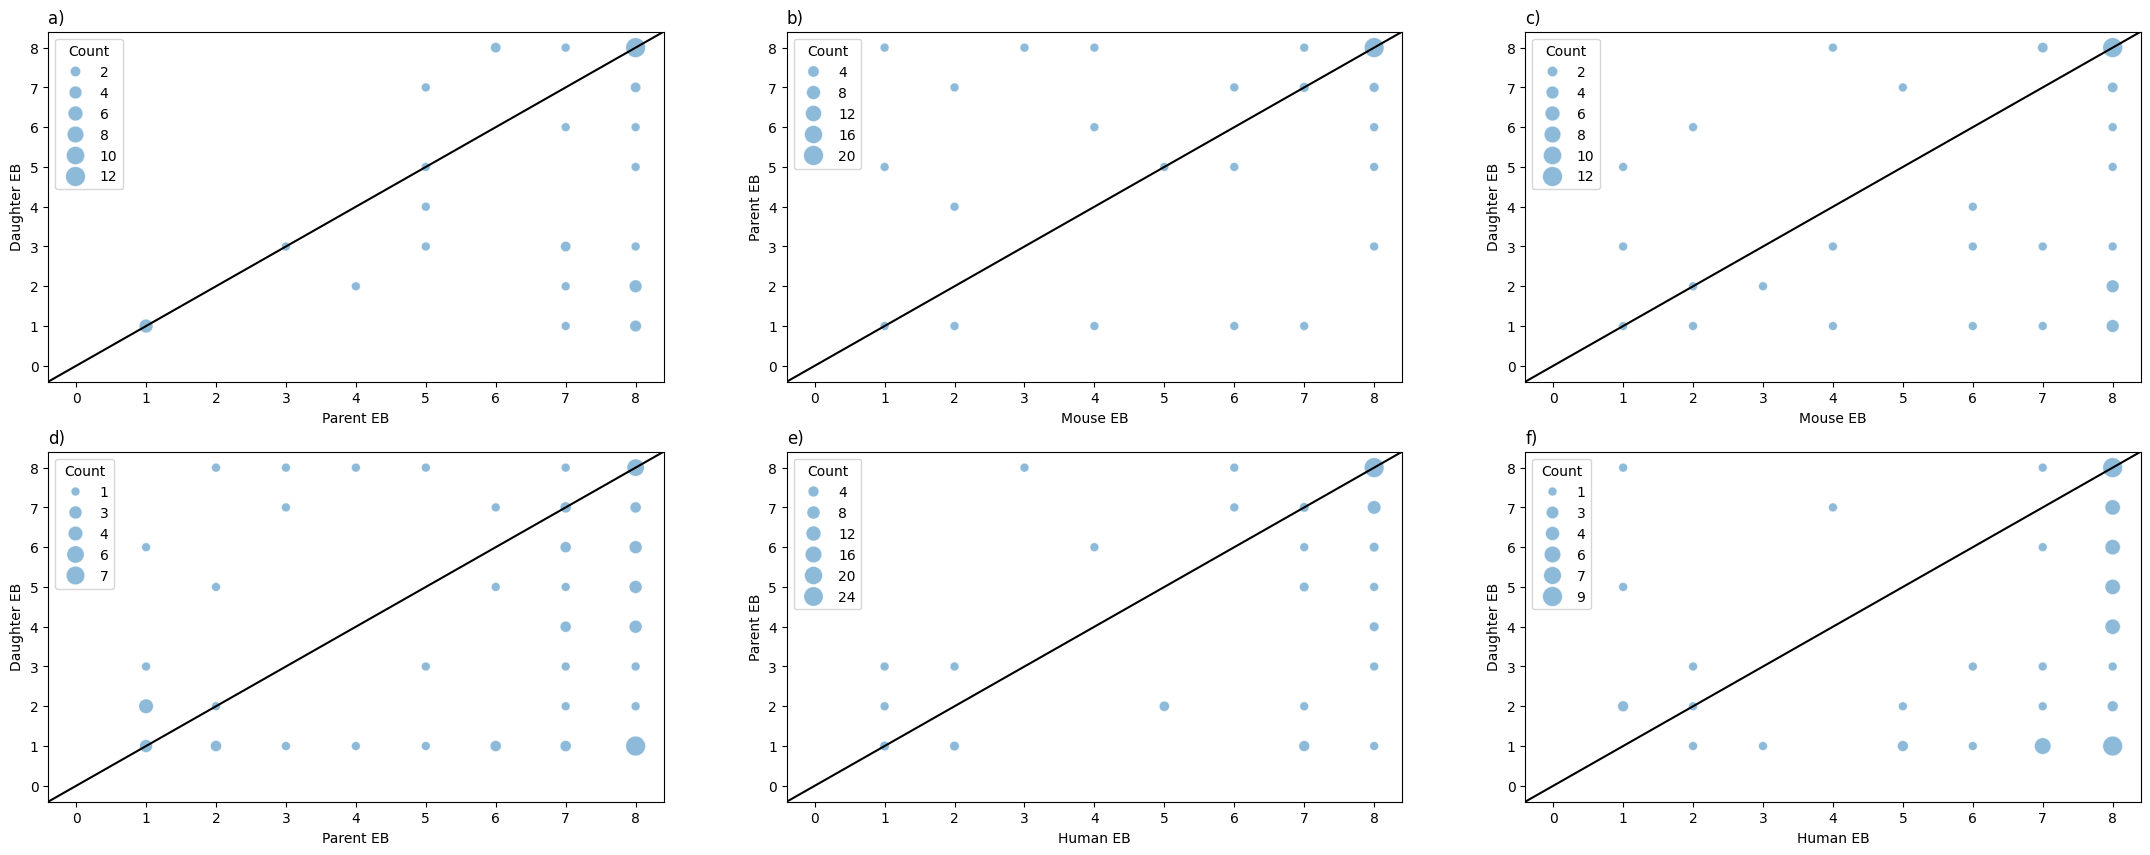

In [ ]:
humanPD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet")
mousePD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet")
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")

humanPD = humanPD.merge(orthoTable[["Mouse gene stable ID", "Gene stable ID", "Mouse EB", "Mouse Tau", "Human EB", "Human Tau"]], left_on=["Mouse Gene", "Human Parent"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"Human EB": "Parent EB", "Human Tau": "Parent Tau"})
humanPD = humanPD.merge(orthoTable[["Mouse gene stable ID", "Gene stable ID", "Human EB", "Human Tau"]], left_on=["Mouse Gene", "Human Daughter"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"Human EB": "Daughter EB", "Human Tau": "Daughter Tau"})
mousePD = mousePD.merge(orthoTable[["Mouse gene stable ID", "Gene stable ID", "Human EB", "Human Tau", "Mouse EB", "Mouse Tau"]], left_on=["Human Gene", "Mouse Parent"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"Mouse EB": "Parent EB", "Mouse Tau": "Parent Tau"})
mousePD = mousePD.merge(orthoTable[["Mouse gene stable ID", "Gene stable ID", "Mouse EB", "Mouse Tau"]], left_on=["Human Gene", "Mouse Daughter"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"Mouse EB": "Daughter EB", "Mouse Tau": "Daughter Tau"})

dfList = [humanPD, mousePD]
speciesPairs = [("Mouse", "Human"), ("Human", "Mouse")]
for metric in ["Tau", "EB"]:
    fig, axes = plt.subplots(2, 3, figsize=(27, 10))
    for dfIdx, (nonDuplicatedSpecies, duplicatedSpecies) in enumerate(speciesPairs):
        rowLabels = [
            f"Parent {metric} vs Daughter {metric}",
            f"{nonDuplicatedSpecies} {metric} vs Parent {metric}",
            f"{nonDuplicatedSpecies} {metric} vs Daughter {metric}"
        ]
        colLabels = [
            "numAboveLine (Y>X)", "numBelowLine (Y<X)", "totalNum", "pValue"
        ]
        statsDF = pd.DataFrame(index=rowLabels, columns=colLabels)
        comparisons = [
            (f"Parent {metric}", f"Daughter {metric}", f"{duplicatedSpecies.lower()}ParentVS{duplicatedSpecies.lower()}Daughter"),
            (f"{nonDuplicatedSpecies} {metric}", f"Parent {metric}", f"{nonDuplicatedSpecies.lower()}VS{duplicatedSpecies.lower()}Parent"),
            (f"{nonDuplicatedSpecies} {metric}", f"Daughter {metric}", f"{nonDuplicatedSpecies.lower()}VS{duplicatedSpecies.lower()}Daughter")
        ]
        df = dfList[dfIdx]
        for groupIdx, (xCol, yCol, fileName) in enumerate(comparisons):
            dfFiltered = df.dropna(subset=[xCol, yCol])

            numAboveLine = (dfFiltered[yCol] > dfFiltered[xCol]).sum()
            numBelowLine = (dfFiltered[yCol] < dfFiltered[xCol]).sum()
            totalNum = dfFiltered.shape[0]
            res = stats.binomtest(numAboveLine, numAboveLine + numBelowLine, p=0.5)

            statsDF.iloc[groupIdx, 0] = numAboveLine
            statsDF.iloc[groupIdx, 1] = numBelowLine
            statsDF.iloc[groupIdx, 2] = totalNum 
            statsDF.iloc[groupIdx, 3] = res.pvalue 

            dfCounts = df.groupby([xCol, yCol]).size().reset_index(name="Count")
            ax = sns.scatterplot(data=dfCounts, x=xCol, y=yCol, size="Count", sizes=(40, 200), alpha=0.5, legend='brief', ax=axes[dfIdx][groupIdx])
            ax.axline((0, 0), slope=1, color="black", linewidth=1.5)
            ax.set_title(f"{chr(ord("`")+(dfIdx * 3 + groupIdx + 1))})", loc="left")
            filePath = f"/Users/andrewhsu/Projects/McNair/plots/parentDaughter{metric}Corr/{fileName}.png"
        with pd.ExcelWriter(f"/Users/andrewhsu/Projects/McNair/data/{duplicatedSpecies.lower()}{metric}Binom.xlsx") as w:
            statsDF.T.to_excel(w, sheet_name="Sheet1", index=True)
    plt.savefig(f"/Users/andrewhsu/Projects/McNair/plots/parentDaughter{metric}.png", dpi=300)
    plt.show()
    plt.close()


In [52]:
orthoTable = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/orthologTableDistDupeBioTypeParentalDaughterGOEPExondNdSProtIDTauEBModeEvol.parquet")

humanPD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/humanParentDaughter.parquet")
mousePD = pd.read_parquet("/Users/andrewhsu/Projects/McNair/data/mouseParentDaughter.parquet")

humanPD = humanPD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Human Exons", "+/-"]], left_on=["Mouse Gene", "Human Parent"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Parent", "Number of Human Exons": "Number of Parent Exons", "+/-": "+/- Parent"})
humanPD = humanPD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Human Exons", "+/-"]], left_on=["Mouse Gene", "Human Daughter"], right_on=["Mouse gene stable ID", "Gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Daughter", "Number of Human Exons": "Number of Daughter Exons", "+/-": "+/- Daughter"})

mousePD = mousePD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Mouse Exons", "+/-"]], left_on=["Human Gene", "Mouse Parent"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Parent", "Number of Mouse Exons": "Number of Parent Exons", "+/-": "+/- Parent"})
mousePD = mousePD.merge(orthoTable[["Gene stable ID", "Mouse gene stable ID", "dN/dS", "Number of Mouse Exons", "+/-"]], left_on=["Human Gene", "Mouse Daughter"], right_on=["Gene stable ID", "Mouse gene stable ID"], how="left").drop(columns=["Mouse gene stable ID", "Gene stable ID"]).rename(columns={"dN/dS": "dN/dS Daughter", "Number of Mouse Exons": "Number of Daughter Exons", "+/-": "+/- Daughter"})    

humanPDNoRetro = humanPD[(humanPD["Number of Parent Exons"] != 1) & (humanPD["Number of Daughter Exons"] != 1)]
humanPDNoOverUnderRepresentation = humanPD[(humanPD["+/- Parent"] == "nan") & (humanPD["+/- Daughter"] == "nan")]
mousePDNoRetro = mousePD[(mousePD["Number of Parent Exons"] != 1) & (mousePD["Number of Daughter Exons"] != 1)]
mousePDNoOverUnderRepresentation = mousePD[(mousePD["+/- Parent"] == "nan") & (mousePD["+/- Daughter"] == "nan")]

In [53]:
print(stats.wilcoxon(humanPDNoRetro[humanPDNoRetro["PearDist Parent"].notna()]["PearDist Parent"], humanPDNoRetro[humanPDNoRetro["PearDist Daughter"].notna()]["PearDist Daughter"]))
print(stats.wilcoxon(mousePDNoRetro[mousePDNoRetro["PearDist Parent"].notna()]["PearDist Parent"], mousePDNoRetro[mousePDNoRetro["PearDist Daughter"].notna()]["PearDist Daughter"]))

WilcoxonResult(statistic=np.float64(181.0), pvalue=np.float64(0.0028939764633832965))
WilcoxonResult(statistic=np.float64(439.0), pvalue=np.float64(0.02280240301003519))


In [54]:
print(stats.wilcoxon(humanPDNoRetro[humanPDNoRetro["PearDist Parent"].notna()]["PearDist Parent"], humanPDNoRetro[humanPDNoRetro["PearDist Daughter"].notna()]["PearDist Daughter"]))
print(stats.wilcoxon(mousePDNoRetro[mousePDNoRetro["PearDist Parent"].notna()]["PearDist Parent"], mousePDNoRetro[mousePDNoRetro["PearDist Daughter"].notna()]["PearDist Daughter"]))

WilcoxonResult(statistic=np.float64(181.0), pvalue=np.float64(0.0028939764633832965))
WilcoxonResult(statistic=np.float64(439.0), pvalue=np.float64(0.02280240301003519))


In [55]:
print(stats.wilcoxon(humanPDNoOverUnderRepresentation[humanPDNoOverUnderRepresentation["PearDist Parent"].notna()]["PearDist Parent"], humanPDNoOverUnderRepresentation[humanPDNoOverUnderRepresentation["PearDist Daughter"].notna()]["PearDist Daughter"]))
print(stats.wilcoxon(mousePDNoOverUnderRepresentation[mousePDNoOverUnderRepresentation["PearDist Parent"].notna()]["PearDist Parent"], mousePDNoOverUnderRepresentation[mousePDNoOverUnderRepresentation["PearDist Daughter"].notna()]["PearDist Daughter"]))

WilcoxonResult(statistic=np.float64(178.0), pvalue=np.float64(0.11064805556088686))
WilcoxonResult(statistic=np.float64(203.0), pvalue=np.float64(0.004653470972698415))
